# 🌿 Scénario — Classification *Ambrosia artemisiifolia* avec **YOLO26n-cls**

| Élément | Valeur |
|---|---|
| Modèle principal | **`yolo26n-cls.pt`**

Tout le reste (Phases 0 à 11) suit strictement la même logique que le notebook d'origine yolo11n-cls: téléchargement iNaturalist, GBIF fallback, split 70/20/10 par `obs_id`, deux phases de transfer learning, évaluation complète, Grad-CAM, exports ONNX/TFLite.


## 💾 PHASE 0a — Montage Google Drive

Monter Google Drive permet de **sauvegarder automatiquement** le modèle entraîné, les métriques,
les figures et la fiche technique entre les sessions Colab. Le dossier de travail est créé dans
`My Drive/1er scénario_herbe_a_poux_yolo26ncls/`. Toutes les sorties y seront copiées en fin de pipeline.

In [1]:
# 0a. Montage Google Drive — sauvegarde persistante
from google.colab import drive
import os
from datetime import datetime

GDRIVE_MOUNT   = '/content/drive'
GDRIVE_PROJECT = os.path.join(
    GDRIVE_MOUNT, 'MyDrive',
    '1er scénario_herbe_a_poux_yolo26ncls'
)

RUN_TAG = datetime.now().strftime('%Y-%m-%d_%Hh%M')

drive.mount(GDRIVE_MOUNT, force_remount=False)
os.makedirs(GDRIVE_PROJECT, exist_ok=True)

# Sous-dossiers organisés
GDRIVE_SUBDIRS = {
    'photos_pos' : os.path.join(GDRIVE_PROJECT, 'Photos_Positifs'),
    'photos_neg' : os.path.join(GDRIVE_PROJECT, 'Photos_Negatifs'),
    'modeles'    : os.path.join(GDRIVE_PROJECT, 'Modeles'),
    'metriques'  : os.path.join(GDRIVE_PROJECT, 'Metriques'),
    'figures'    : os.path.join(GDRIVE_PROJECT, 'Figures'),
    'logs'       : os.path.join(GDRIVE_PROJECT, 'Logs'),
    'exports'    : os.path.join(GDRIVE_PROJECT, 'Exports'),
    'metadata'   : os.path.join(GDRIVE_PROJECT, 'Metadata'),
    'runs'       : os.path.join(GDRIVE_PROJECT, 'Runs'),
    'photos_val' : os.path.join(GDRIVE_PROJECT, 'Photos_Val'),
    'photos_test': os.path.join(GDRIVE_PROJECT, 'Photos_Test'),
}

GDRIVE_RUN = os.path.join(GDRIVE_SUBDIRS['runs'], f'run_{RUN_TAG}')
for path in list(GDRIVE_SUBDIRS.values()) + [GDRIVE_RUN]:
    os.makedirs(path, exist_ok=True)

print(f'✅ Google Drive monté  : {GDRIVE_MOUNT}')
print(f'✅ Dossier projet      : {GDRIVE_PROJECT}')
print(f'✅ Run actuel          : {GDRIVE_RUN}')
print()
print('📁 Structure :')
for name, path in GDRIVE_SUBDIRS.items():
    print(f'   {name:<15} → {path}')


Mounted at /content/drive
✅ Google Drive monté  : /content/drive
✅ Dossier projet      : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls
✅ Run actuel          : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Runs/run_2026-06-19_11h58

📁 Structure :
   photos_pos      → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Photos_Positifs
   photos_neg      → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Photos_Negatifs
   modeles         → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Modeles
   metriques       → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Metriques
   figures         → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Figures
   logs            → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Logs
   exports         → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Exports
   metadata        → /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Metadat

# 🌿 Classification de l'Herbe à Poux — YOLOv26n-cls
Pipeline complet · selon la méthodologie de l'étude — 20 espèces — Scénario 1

---

## L'herbe à poux (*Ambrosia artemisiifolia*)

<p align="center">
  <img src="https://inaturalist-open-data.s3.amazonaws.com/photos/570670867/medium.jpg"
       alt="Ambrosia artemisiifolia — Herbe à poux" width="480"/>
  <br/>
  <em>Ambrosia artemisiifolia</em> — Photo : omar_guettache · 22 sept. 2025 · Sherbrooke, QC<br/>
  <a href="https://www.inaturalist.org/observations/315879295" target="_blank">
  Observation #315879295</a> · Projet Herbe à Poux UdS · iNaturalist (CC BY-NC)
</p>

L'herbe à poux (*Ambrosia artemisiifolia*) est une plante annuelle envahissante originaire
d'Amérique du Nord. Elle constitue la **principale source de pollen allergène au Québec**,
affectant environ 1 Québécois sur 8 durant la saison pollinique (août–septembre). Son pollen
est responsable de rhinites allergiques, de conjonctivites et d'exacerbations d'asthme.

---

## Objectif du projet

Ce notebook entraîne un **classifieur binaire** capable de distinguer l'herbe à poux
d'espèces visuellement similaires, à partir de photos citoyennes iNaturalist.

**Protocole de collecte :**
- **Classe positive** : **exclusivement** les observations du projet
  [Herbe à Poux UdS — site Sherbrooke](https://www.inaturalist.org/projects/herbe-a-poux-uds-site-sherbrooke)
  (qualité de recherche). Aucun complément extérieur au projet.
- **Classe négative** : 20 espèces morphologiquement proches depuis **toute la plateforme
  iNaturalist** (qualité de recherche, aucune restriction géographique).

Le modèle **YOLOv26n-cls** (transfer learning ImageNet) n'est **pas modifié** architecturalement.

---

| Phase | Description |
|---|---|
| 💾 Phase 0a | Montage Google Drive |
| ⚙️ Phase 0b | Configuration & Installation |
| 📥 Phase 1 | Collecte iNaturalist (projet + plateforme) |
| 🧹 Phase 2 | Téléchargement, Nettoyage & Standardisation |
| ✂️ Phase 3 | Partitionnement Stratifié 70/20/10 |
| 🏋️ Phase 4 | Entraînement Transfer Learning (2 phases) |
| 📡 Phase 5 | Validation en temps réel |
| 📊 Phase 6 | Diagnostic des courbes |
| 📈 Phase 7 | Métriques — Top-1 · Top-5 · F1 · Kappa · ROC-AUC (IC 95%) |
| 🔬 Phase 8 | Analyse qualitative + Grad-CAM |
| 🗺️ Phase 8e | Carte géographique (Sherbrooke) |
| ✅ Phase 9 | Performance acceptable ? F1 ≥ 0.90 |
| 🚀 Phase 10 | Export ONNX & Fiche technique |
| 🔬 Phase 11 | Inférence interactive |


## ⚙️ PHASE 0b — Configuration & Installation

Cette cellule installe toutes les dépendances Python nécessaires (Ultralytics, MLflow, folium, etc.)
et configure le logging structuré, les seeds de reproductibilité et la vérification GPU.
Toute la suite du notebook repose sur ces imports.

In [2]:
# Cellule volontairement vide (pandas est installé avec les autres dépendances en cellule suivante)
# (L'ancienne ligne "!pip install pandas" était redondante)


In [3]:
# 0b-ii. Installation des dependances
# --- Installation des dependances (v5.1 — sans mlflow pip) ---
# mlflow crée des conflits numpy irresolubles dans Colab 2025
# → remplacé par un stub léger (même API, logs JSON locaux)
!pip install -q ultralytics split-folders pandas requests tqdm \
               scikit-learn seaborn matplotlib opencv-python-headless folium

import os, shutil, json, time, random, hashlib, warnings, concurrent.futures, logging, glob
from pathlib import Path
from typing import Optional, List, Dict, Tuple
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import splitfolders

# --- Logging structure ---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-7s | %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger('herbe_a_poux')

# --- MLflow stub : même API, pas de dépendance externe ---
import json as _json, os as _os, time as _time
class _Run:
    def __init__(self, name): self.name = name; self._params = {}; self._metrics = {}
class _MlflowStub:
    def __init__(self): self._runs = []; self._active = None
    def set_experiment(self, name): pass
    def start_run(self, run_name='', nested=False):
        self._active = _Run(run_name); return self
    def __enter__(self): return self
    def __exit__(self, *a):
        if self._active:
            self._runs.append({'name': self._active.name,
                                'params': self._active._params,
                                'metrics': self._active._metrics})
    def log_param(self, k, v):
        if self._active: self._active._params[str(k)] = str(v)
    def log_params(self, d):
        for k,v in d.items(): self.log_param(k,v)
    def log_metric(self, k, v, step=None):
        if self._active: self._active._metrics[str(k)] = float(v)
    def log_metrics(self, d, step=None):
        for k,v in d.items(): self.log_metric(k,v)
    def log_artifact(self, path): pass
    def set_tag(self, k, v): pass
mlflow = _MlflowStub()
log.info('MLflow stub actif (pas de conflits numpy)')
import torch
import torch.nn as nn
import torch.nn.functional as F
import folium
from folium.plugins import MarkerCluster
from PIL import Image
from tqdm.notebook import tqdm
from ultralytics import YOLO
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    balanced_accuracy_score, cohen_kappa_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, auc
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

log.info('Installation et imports completes.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Configuration centrale
Le modèle reste **`yolo26n-cls.pt`** — aucune modification architecturale.

In [4]:
# 0c. CONFIGURATION CENTRALE (20 espèces terrain — Scénario 1)
# TARGET_COUNT : calculé dynamiquement en Phase 1b depuis l'API iNaturalist
# À ce jour : 605 photos research grade validées par la communauté
# déficit Polygonum+Thymus (55 photos) redistribué uniquement vers Plantago, Artemisia, Melilotus

CONFIG = {
    # --- Données ---
    'PROJECT_SLUG'     : 'herbe-a-poux-uds-site-sherbrooke',
    'PROJECT_URL'      : 'https://www.inaturalist.org/projects/herbe-a-poux-uds-site-sherbrooke',
    # TARGET_COUNT calculé dynamiquement en Phase 1b (nombre réel research grade du projet)
    'LAT_SHK'          : 45.40,
    'LNG_SHK'          : -71.89,
    'RADIUS_KM'        : 50,

    # --- Classes négatives (Top 20 espèces du terrain ) ---
    # Quota par espèce = TARGET_COUNT // 20, redistribution automatique du déficit
    'SIMILAR_SPECIES'  : [
        'Plantago major',              # Grand plantain          — 333 obs —
        'Artemisia vulgaris',          # Armoise commune         — 141 obs —
        'Melilotus albus',             # Mélilot blanc           — 118 obs —
        'Daucus carota',               # Carotte sauvage         —  38 obs —
        'Solidago canadensis',         # Verge-d'or du Canada   —  31 obs —
        'Chenopodium album',           # Chénopode blanc         —  29 obs —
        'Tanacetum vulgare',           # Tanaisie commune        —  26 obs —
        'Erigeron canadensis',         # Érigéron du Canada      —  25 obs —
        'Artemisia absinthium',        # Armoise absinthe        —  22 obs —
        'Matricaria discoidea',        # Matricaire odorante     —  18 obs —
        'Symphyotrichum lanceolatum',  # Aster lancéolé          —  16 obs —
        'Solidago rugosa',             # Verge-d'or rugueuse    —  11 obs —
        'Onoclea sensibilis',          # Onoclée sensible        —  11 obs —
        'Vicia cracca',                # Vesce jargeau           —  10 obs —
        'Polygonum aviculare',         # Renouée des oiseaux     —  10 obs —
        'Thymus praecox',              # Serpolet couché         —   9 obs —
        'Achillea millefolium',        # Achillée millefeuille   —   9 obs —
        'Galium mollugo',              # Gaillet commun          —   8 obs —
        'Lythrum salicaria',           # Salicaire commune       —   8 obs —
        'Lotus corniculatus',          # Lotier corniculé        —   8 obs —
    ],

    # --- Chemins ---
    'RAW_DIR'          : 'data/Herbe_a_poux',
    'SPLIT_DIR'        : 'data/split',
    'GDRIVE_PROJECT'   : GDRIVE_PROJECT,

    # --- Modèle ---
    'MODEL_NAME'       : 'yolo26n-cls.pt',
    'IMG_SIZE'         : 224,

    # --- Phase 1 : backbone gelé ---
    'PHASE1_EPOCHS'    : 10,
    'PHASE1_LR'        : 0.001,
    'PHASE1_FREEZE'    : 10,

    # --- Phase 2 : fine-tuning ---
    'PHASE2_EPOCHS'    : 80,
    'PHASE2_LR'        : 5e-5,
    'PHASE2_FREEZE'    : 0,

    # --- Régularisation (renforcée anti-overfitting) ---
    'LABEL_SMOOTHING'  : 0.10,
    'WEIGHT_DECAY'     : 0.001,
    'DROPOUT'          : 0.3,
    'WARMUP_EPOCHS'    : 3,
    'COS_LR'           : True,

    # --- Augmentation améliorée v5.3 ---
    'AUGMENT_MOSAIC'      : 0.5,
    'AUGMENT_MIXUP'       : 0.20,
    'AUGMENT_FLIPUD'      : 0.3,
    'AUGMENT_FLIPLR'      : 0.5,
    'AUGMENT_DEGREES'     : 30,
    'AUGMENT_ERASING'     : 0.3,
    'AUGMENT_SCALE'       : 0.4,
    'AUGMENT_HSV_H'       : 0.015,
    'AUGMENT_HSV_S'       : 0.7,
    'AUGMENT_HSV_V'       : 0.4,
    'AUGMENT_TRANSLATE'   : 0.15,
    'AUGMENT_PERSPECTIVE' : 0.0005,
    'AUGMENT_SHEAR'       : 5,
    'AUGMENT_COPY_PASTE'  : 0.1,

    # --- Évaluation ---
    'PATIENCE'         : 25,
    'F1_THRESHOLD'     : 0.90,
    'F1_TERRAIN_DELTA' : 0.05,
    'BOOTSTRAP_N'      : 1000,

    # --- MLflow ---
    'MLFLOW_EXPERIMENT': 'Ambrosia_YOLOv11_v5.1_20sp_Scenario1',
}

RUNTIME = {
    'phase1_save_dir': None,
    'phase2_save_dir': None,
    'best_model_path': None,
}

mlflow.set_experiment(CONFIG['MLFLOW_EXPERIMENT'])

log.info('=== CONFIGURATION Scénario 1 ===')
log.info(f'  Modèle        : {CONFIG["MODEL_NAME"]}')
log.info(f'  TARGET_COUNT  : dynamique (calculé en Phase 1b via API iNaturalist)')
log.info(f'  Classes nég.  : {len(CONFIG["SIMILAR_SPECIES"])} espèces (Top 20 terrain)')
log.info(f'  Seuil F1      : {CONFIG["F1_THRESHOLD"]}')
log.info(f'  Phase 2       : {CONFIG["PHASE2_EPOCHS"]} epochs, lr={CONFIG["PHASE2_LR"]}')
log.info(f'  Drive         : {CONFIG["GDRIVE_PROJECT"]}')


## 📥 PHASE 1 — Collecte iNaturalist

### Classe positive — Projet Sherbrooke exclusivement

La classe positive utilise **uniquement** les observations du projet
[Herbe à Poux UdS — site Sherbrooke](https://www.inaturalist.org/projects/herbe-a-poux-uds-site-sherbrooke).
**Aucune observation extérieure au projet n'est ajoutée**, même si le quota n'est pas atteint.
Cela garantit la cohérence géographique et méthodologique des données positives.

Seules les observations **« qualité de recherche »** (`quality_grade=research`) sont retenues.

### Classe négative — 20 espèces terrain + API iNaturalist

La classe négative est constituée des **20 espèces confondantes** sélectionnées par un protocole multicritère appliqué aux données de terrain de Sherbrooke (Omar_Uds.csv, fritzno_Uds.csv, Wilfix_Uds.csv).

**Stratégie de collecte:**
1. **Priorité CSV terrain** — observations des assistants de recherche (research grade en priorité)
2. **Fallback API iNaturalist** — complément automatique si le quota n'est pas atteint via CSV

**Quota** : `TARGET_COUNT // 20` images par espèce, avec redistribution automatique du déficit.

| # | Espèce | Nom commun | Obs. terrain |   |  
|---|---|---|---|---|
| 1 | *Plantago major* | Grand plantain | 333 |
| 2 | *Artemisia vulgaris* | Armoise commune | 141
| 3 | *Melilotus albus* | Mélilot blanc | 118 |
| 4 | *Daucus carota* | Carotte sauvage | 38 |
| 5 | *Solidago canadensis* | Verge-d'or du Canada | 31 |
| 6 | *Chenopodium album* | Chénopode blanc | 29 |
| 7 | *Tanacetum vulgare* | Tanaisie commune | 26 |
| 8 | *Erigeron canadensis* | Érigéron du Canada | 25 |
| 9 | *Artemisia absinthium* | Armoise absinthe | 22 |
| 10 | *Matricaria discoidea* | Matricaire odorante | 18 |
| 11 | *Symphyotrichum lanceolatum* | Aster lancéolé | 16 ||
| 12 | *Solidago rugosa* | Verge-d'or rugueuse | 11 |
| 13 | *Onoclea sensibilis* | Onoclée sensible | 11 |
| 14 | *Vicia cracca* | Vesce jargeau | 10 |
| 15 | *Polygonum aviculare* | Renouée des oiseaux | 10 |
| 16 | *Thymus praecox* | Serpolet couché | 9 |
| 17 | *Achillea millefolium* | Achillée millefeuille | 9 |
| 18 | *Galium mollugo* | Gaillet commun | 8 |
| 19 | *Lythrum salicaria* | Salicaire commune | 8 |
| 20 | *Lotus corniculatus* | Lotier corniculé | 8 |



In [5]:
# 1a. Fonctions collecte iNaturalist
INAT_API_URL = 'https://api.inaturalist.org/v1/observations'
INAT_PER_PAGE = 200
INAT_DELAY_S  = 0.5

def fetch_inat_obs(params: dict, max_count: int, description: str,
                   ids_autorises: set = None) -> list:
    """Collecte paginée depuis l'API iNaturalist (quality_grade=research).
    Si ids_autorises est fourni, seules les observations dont l'id figure
    dans cet ensemble sont retenues (filtre CSV).
    """
    all_obs, page, consecutive_errors = [], 1, 0
    log.info(f'Collecte : {description} (cible : {max_count})')
    while len(all_obs) < max_count:
        p = {**params, 'per_page': INAT_PER_PAGE, 'page': page,
             'order': 'desc', 'order_by': 'updated_at'}
        try:
            r = requests.get(INAT_API_URL, params=p, timeout=20)
            r.raise_for_status(); data = r.json(); consecutive_errors = 0
        except requests.exceptions.HTTPError as e:
            log.warning(f'Erreur HTTP page {page}: {e}')
            consecutive_errors += 1
            if consecutive_errors >= 3: break
            time.sleep(2); continue
        except requests.exceptions.RequestException as e:
            log.warning(f'Erreur réseau page {page}: {e}')
            consecutive_errors += 1
            if consecutive_errors >= 3: break
            time.sleep(2); continue
        results = data.get('results', [])
        if not results: break
        valid = [obs for obs in results if obs.get('photos')]
        # ── Filtre CSV : on n'accepte que les ids connus ──────────────
        if ids_autorises is not None:
            valid = [o for o in valid if str(o.get('id', '')) in ids_autorises]
        needed = max_count - len(all_obs)
        all_obs.extend(valid[:needed])
        log.info(f'  Page {page}: {len(valid)} obs (filtrées) -> cumul {len(all_obs)}/{max_count}')
        page += 1; time.sleep(INAT_DELAY_S)
        if len(results) < INAT_PER_PAGE: break
    return all_obs

# ─────────────────────────────────────────────────────────────
# 1b. CLASSE POSITIVE — Requête dynamique à l'API iNaturalist
#     Scénario 1 : la source est le projet Sherbrooke (research grade).
#     ids_autorises = IDs collectés via API  ∪  IDs des 3 CSV terrain
# ─────────────────────────────────────────────────────────────
log.info('=== CLASSE POSITIVE : Projet Sherbrooke — comptage dynamique ===')
log.info(f'  Projet : {CONFIG["PROJECT_URL"]}')

# Étape 1 : compter le nombre réel de photos research grade disponibles
count_resp = requests.get(
    INAT_API_URL,
    params={
        'project_id'   : CONFIG['PROJECT_SLUG'],
        'quality_grade': 'research',
        'per_page'     : 1,
        'page'         : 1,
    },
    timeout=20
)
count_resp.raise_for_status()
TOTAL_AVAILABLE = count_resp.json().get('total_results', 0)
log.info(f'  Photos research grade disponibles (API temps réel) : {TOTAL_AVAILABLE}')

# Étape 2 : fixer TARGET_COUNT = nombre réel disponible
TARGET_COUNT = TOTAL_AVAILABLE
CONFIG['TARGET_COUNT'] = TARGET_COUNT
log.info(f'  TARGET_COUNT fixé à : {TARGET_COUNT}')

# Étape 3 : collecter toutes les observations (sans filtre — toutes research grade du projet)
ambrosia_obs_raw = fetch_inat_obs(
    {'project_id': CONFIG['PROJECT_SLUG'], 'quality_grade': 'research'},
    TARGET_COUNT,
    f"Projet {CONFIG['PROJECT_SLUG']} (research grade)"
)

# ── Étape 4 : Pré-chargement des 3 CSV terrain ───────────────────────────────
import pandas as pd
from google.colab import files as colab_files

print('\n⬆️  Veuillez uploader les 3 fichiers CSV terrain :')
print('   Omar_Uds.csv, fritzno_Uds.csv, Wilfix_Uds.csv')
print('   (Ces fichiers seront aussi utilisés pour la classe négative en cell 10)')
uploaded = colab_files.upload()

csv_frames_pre = []
for fname in ['Omar_Uds.csv', 'fritzno_Uds.csv', 'Wilfix_Uds.csv']:
    if fname in uploaded or os.path.exists(fname):
        try:
            df = pd.read_csv(fname)
            csv_frames_pre.append(df)
            log.info(f'  ✅ {fname} : {len(df)} lignes')
        except Exception as e:
            log.warning(f'  ⚠ {fname} : erreur ({e})')
    else:
        log.warning(f'  ⚠ {fname} non trouvé — ignoré')

if csv_frames_pre:
    df_terrain_pre = pd.concat(csv_frames_pre, ignore_index=True)
    # FIX : dédupliquer sur 'uuid' si présent, sinon sur 'id'
    dedup_col = 'uuid' if 'uuid' in df_terrain_pre.columns else 'id'
    if dedup_col in df_terrain_pre.columns:
        df_terrain_pre = df_terrain_pre.drop_duplicates(subset=dedup_col)
        log.info(f'  Déduplication sur colonne : {dedup_col}')
    else:
        log.warning('  Ni uuid ni id trouvés — pas de déduplication')
    ids_csv_terrain_pre = set(df_terrain_pre['id'].astype(str)) if 'id' in df_terrain_pre.columns else set()
    log.info(f'  IDs CSV terrain (pré-chargement) : {len(ids_csv_terrain_pre)}')
else:
    df_terrain_pre      = pd.DataFrame()
    ids_csv_terrain_pre = set()
    log.warning('  Aucun CSV terrain pré-chargé')

# ── Étape 5 : Construire ids_autorises ────────────────────────
ids_api_positifs = {str(o['id']) for o in ambrosia_obs_raw}
ids_autorises    = ids_api_positifs | ids_csv_terrain_pre
log.info(f'  IDs autorisés total : {len(ids_autorises)} '
         f'(API positifs={len(ids_api_positifs)}, CSV terrain={len(ids_csv_terrain_pre)})')

# ── Étape 6 : Finaliser ambrosia_obs avec lat_csv/lng_csv ─────
ambrosia_obs = []
terrain_idx  = {}
if not df_terrain_pre.empty and 'id' in df_terrain_pre.columns:
    for _, row in df_terrain_pre.iterrows():
        terrain_idx[str(row['id'])] = row

for obs in ambrosia_obs_raw:
    oid = str(obs['id'])
    row = terrain_idx.get(oid)
    obs['lat_csv'] = float(row['latitude'])  if row is not None and pd.notna(row.get('latitude'))  else None
    obs['lng_csv'] = float(row['longitude']) if row is not None and pd.notna(row.get('longitude')) else None
    ambrosia_obs.append(obs)

EFFECTIVE_TARGET = len(ambrosia_obs)
log.info(f'=== Classe positive : {EFFECTIVE_TARGET} observations collectées ===')
log.info(f'  Quota classe négative (par espèce) : ~{EFFECTIVE_TARGET // len(CONFIG["SIMILAR_SPECIES"])} imgs')
log.info(f'  ids_autorises exposé pour filtrage classe négative + carte')



⬆️  Veuillez uploader les 3 fichiers CSV terrain :
   Omar_Uds.csv, fritzno_Uds.csv, Wilfix_Uds.csv
   (Ces fichiers seront aussi utilisés pour la classe négative en cell 10)


Saving Omar_Uds.csv to Omar_Uds.csv
Saving fritzno_Uds.csv to fritzno_Uds.csv
Saving Wilfix_Uds.csv to Wilfix_Uds.csv


In [6]:
# 1c. Classe NÉGATIVE —: CSV terrain → API iNaturalist géo-filtrée → GBIF
#
# Stratégie en 3 sources (ordre de priorité) :
#   Source 1 — CSV terrain     : IDs validés terrain, RG en priorité
#   Source 2 — API iNaturalist : géo-filtrée (Sherbrooke ±50 km), research grade
#                                SANS filtre ids_autorises (réservé à la classe positive)
#   Source 3 — API GBIF        : complément final si déficit résiduel après sources 1+2
#                                géo-filtrée (bbox Sherbrooke), StillImage, HUMAN_OBSERVATION
#
# CORRECTION: ids_autorises ne s'applique qu'à la classe positive.
# AJOUT     : GBIF comme 3e source pour combler les déficits résiduels.
#           : redistribution ciblée du déficit → Plantago, Artemisia, Melilotus uniquement.
#
log.info('=== CLASSE NÉGATIVE : CSV → iNat géo-filtré → GBIF ===')

import pandas as pd
import math

# ── Réutilisation du df_terrain chargé en cell 9 ──────────────────────────
if not df_terrain_pre.empty:
    df_terrain = df_terrain_pre.copy()
    log.info(f'  df_terrain réutilisé depuis cell 9 : {len(df_terrain)} observations')
else:
    df_terrain = pd.DataFrame()
    log.warning('  Aucun CSV terrain disponible — collecte 100% via API')

log.info(f'  ids_autorises : {len(ids_autorises)} IDs (réservé à la classe positive)')

# ── Paramètres géographiques ───────────────────────────────────────────────
LAT_SHK   = CONFIG['LAT_SHK']    # 45.40
LNG_SHK   = CONFIG['LNG_SHK']    # -71.89
RADIUS_KM = CONFIG['RADIUS_KM']  # 50

# Bounding box pour GBIF (±~0.45° ≈ 50 km)
_D = RADIUS_KM / 111.0
GBIF_LAT_MIN = LAT_SHK - _D
GBIF_LAT_MAX = LAT_SHK + _D
GBIF_LNG_MIN = LNG_SHK - _D / math.cos(math.radians(LAT_SHK))
GBIF_LNG_MAX = LNG_SHK + _D / math.cos(math.radians(LAT_SHK))
GBIF_API_URL  = 'https://api.gbif.org/v1/occurrence/search'
GBIF_DELAY_S  = 0.3

# ── Audit CSV disponible par espèce ───────────────────────────────────────
log.info('')
log.info('  --- Audit disponibilité CSV par espèce ---')
log.info(f'  {"Espèce":<38} {"Total":>6}  {"RG":>6}  {"NeedsID":>8}  {"img_url":>8}')
log.info(f'  {"-"*72}')
audit_csv = {}
for sp in CONFIG['SIMILAR_SPECIES']:
    if df_terrain.empty:
        audit_csv[sp] = {'total': 0, 'rg': 0, 'needs_id': 0, 'with_img': 0}
        continue
    sub      = df_terrain[df_terrain['scientific_name'] == sp]
    with_img = sub[sub['image_url'].notna() & (sub['image_url'] != '')]
    n_rg     = int((with_img['quality_grade'] == 'research').sum())
    n_needs  = int((with_img['quality_grade'] != 'research').sum())
    audit_csv[sp] = {'total': len(sub), 'rg': n_rg, 'needs_id': n_needs, 'with_img': len(with_img)}
    flag = ' ⚠️' if len(with_img) == 0 else ''
    log.info(f'  {sp:<38} {len(sub):>6}  {n_rg:>6}  {n_needs:>8}  {len(with_img):>8}{flag}')

# ── Source 1 : extraction CSV (RG en priorité) ────────────────────────────
def csv_obs_for_species(df, species_name, quota):
    """Extrait des observations CSV pour une espèce (RG en priorité)."""
    if df.empty:
        return []
    sub = df[
        (df['scientific_name'] == species_name) &
        (df['image_url'].notna()) &
        (df['image_url'] != '')
    ].copy()
    rg    = sub[sub['quality_grade'] == 'research']
    other = sub[sub['quality_grade'] != 'research']
    sub_sorted = pd.concat([rg, other]).head(quota)
    obs_list = []
    for _, row in sub_sorted.iterrows():
        url = str(row['image_url']).replace('square', 'original')
        obs_list.append({
            'id'           : str(row['id']),
            'source'       : 'csv_terrain',
            'photos'       : [{'url': url}],
            'taxon'        : {'name': species_name},
            'quality_grade': row.get('quality_grade', 'needs_id'),
            'lat_csv'      : row.get('latitude',  None),
            'lng_csv'      : row.get('longitude', None),
        })
    return obs_list

# ── Source 3 : collecte GBIF ───────────────────────────────────────────────
def fetch_gbif_obs(species_name, n_needed, existing_ids):
    """
    Collecte via l'API GBIF occurrence/search.
    Filtres : scientificName, bbox Sherbrooke, StillImage, HUMAN_OBSERVATION,
              hasCoordinate=True, hasGeospatialIssue=False.
    Retourne une liste d'obs au format interne (même structure que iNat).
    """
    if n_needed <= 0:
        return []

    obs_list = []
    offset   = 0
    limit    = 100   # max GBIF par page
    max_fetch = n_needed + 40

    log.info(f'    [GBIF] {species_name} — besoin={n_needed}, bbox Sherbrooke ±{RADIUS_KM}km')

    while len(obs_list) < max_fetch:
        params = {
            'scientificName'     : species_name,
            'hasCoordinate'      : 'true',
            'hasGeospatialIssue' : 'false',
            'mediaType'          : 'StillImage',
            'basisOfRecord'      : 'HUMAN_OBSERVATION',
            'decimalLatitude'    : f'{GBIF_LAT_MIN},{GBIF_LAT_MAX}',
            'decimalLongitude'   : f'{GBIF_LNG_MIN},{GBIF_LNG_MAX}',
            'limit'              : limit,
            'offset'             : offset,
        }
        try:
            r = requests.get(GBIF_API_URL, params=params, timeout=20)
            r.raise_for_status()
            data = r.json()
        except requests.exceptions.RequestException as e:
            log.warning(f'    [GBIF] Erreur réseau : {e}')
            break

        results = data.get('results', [])
        if not results:
            break

        for rec in results:
            # Extraire l'URL de la première image StillImage
            media = rec.get('media', [])
            img_url = None
            for m in media:
                if m.get('type') == 'StillImage' and m.get('identifier'):
                    img_url = m['identifier']
                    break
            if not img_url:
                continue

            gbif_id = f"gbif_{rec.get('gbifID', rec.get('key', ''))}"
            if gbif_id in existing_ids:
                continue

            obs_list.append({
                'id'           : gbif_id,
                'source'       : 'gbif',
                'photos'       : [{'url': img_url}],
                'taxon'        : {'name': species_name},
                'quality_grade': 'research',   # HUMAN_OBSERVATION GBIF ≈ research
                'lat_csv'      : rec.get('decimalLatitude'),
                'lng_csv'      : rec.get('decimalLongitude'),
            })

        log.info(f'    [GBIF] offset={offset} — {len(results)} résultats, '
                 f'{len(obs_list)} candidats cumulés')

        if data.get('endOfRecords', True):
            break

        offset += limit
        time.sleep(GBIF_DELAY_S)

    collected = obs_list[:n_needed]
    log.info(f'    [GBIF] → {len(collected)} retenus / {n_needed} demandés')
    return collected

# ── Collecte principale par espèce ────────────────────────────────────────
non_ambrosia_obs = []
species_counts   = {}
species_source   = {}
species_detail   = {}

nb_sp      = len(CONFIG['SIMILAR_SPECIES'])
quota_base = EFFECTIVE_TARGET // nb_sp
remainder  = EFFECTIVE_TARGET % nb_sp
shortfall  = 0

log.info('')
log.info(f'  Quota de base : {quota_base} imgs/espèce | Reste : {remainder}')
log.info(f'  EFFECTIVE_TARGET : {EFFECTIVE_TARGET}')
log.info('')

# v5.2 — Redistribution ciblée : le déficit va UNIQUEMENT vers Plantago, Artemisia, Melilotus
PRIORITY_SPECIES = ['Plantago major', 'Artemisia vulgaris', 'Melilotus albus']
priority_shortfall = 0  # accumulateur global du déficit toutes espèces confondues

# Passe 1 : collecter toutes les espèces normalement et mesurer le déficit total
species_deficit_total = 0

for i, sp in enumerate(CONFIG['SIMILAR_SPECIES']):
    quota = quota_base + (1 if i < remainder else 0)

    # ── Source 1 : CSV terrain ────────────────────────────────
    csv_obs   = csv_obs_for_species(df_terrain, sp, quota)
    n_csv     = len(csv_obs)
    n_csv_rg  = sum(1 for o in csv_obs if o['quality_grade'] == 'research')
    n_csv_nid = n_csv - n_csv_rg

    # ── Source 2 : iNaturalist géo-filtré ─────────────────────
    n_needed_inat = quota - n_csv
    inat_obs      = []
    if n_needed_inat > 0:
        existing_ids = {o['id'] for o in csv_obs}
        raw_inat = fetch_inat_obs(
            {
                'taxon_name'   : sp,
                'quality_grade': 'research',
                'lat'          : LAT_SHK,
                'lng'          : LNG_SHK,
                'radius'       : RADIUS_KM,
            },
            n_needed_inat + 20,
            f'{sp} (iNat géo-filtré, besoin={n_needed_inat})',
            ids_autorises=None,  # pas de filtre ID pour le négatif
        )
        inat_obs = [o for o in raw_inat if o['id'] not in existing_ids][:n_needed_inat]

    # ── Source 3 : GBIF (complément si déficit résiduel) ──────
    n_needed_gbif = quota - n_csv - len(inat_obs)
    gbif_obs      = []
    if n_needed_gbif > 0:
        existing_ids = {o['id'] for o in csv_obs + inat_obs}
        gbif_obs = fetch_gbif_obs(sp, n_needed_gbif, existing_ids)

    collected = csv_obs + inat_obs + gbif_obs
    non_ambrosia_obs.extend(collected)
    species_counts[sp] = len(collected)

    src_parts = []
    if n_csv > 0:      src_parts.append('csv')
    if len(inat_obs) > 0: src_parts.append('inat')
    if len(gbif_obs) > 0: src_parts.append('gbif')
    species_source[sp] = '+'.join(src_parts) if src_parts else 'none'

    species_detail[sp] = {
        'quota'    : quota,
        'csv_rg'   : n_csv_rg,
        'csv_nid'  : n_csv_nid,
        'inat'     : len(inat_obs),
        'gbif'     : len(gbif_obs),
        'total'    : len(collected),
        'deficit'  : max(0, quota - len(collected)),
    }

    if len(collected) < quota:
        sp_deficit = quota - len(collected)
        priority_shortfall += sp_deficit
        log.warning(
            f'  ⚠ {sp:<35}: quota={quota} | '
            f'CSV(RG={n_csv_rg} NID={n_csv_nid}) iNat={len(inat_obs)} '
            f'GBIF={len(gbif_obs)} total={len(collected)} — déficit {sp_deficit} → redistribué sur prioritaires'
        )
    else:
        pass  # pas de shortfall
        src_icon = {'csv': '📄', 'csv+inat': '🔀', 'csv+gbif': '🔀',
                    'csv+inat+gbif': '🔀', 'inat': '🌿', 'gbif': '🟡',
                    'inat+gbif': '🔀'}.get(species_source[sp], '✅')
        log.info(
            f'  ✅ {src_icon} {sp:<33}: quota={quota} | '
            f'CSV(RG={n_csv_rg} NID={n_csv_nid}) iNat={len(inat_obs)} '
            f'GBIF={len(gbif_obs)} total={len(collected)}'
        )

# ── Fallback global résiduel ───────────────────────────────────────────────
if len(non_ambrosia_obs) < EFFECTIVE_TARGET:
    deficit = EFFECTIVE_TARGET - len(non_ambrosia_obs)
    log.warning(f'Déficit résiduel global : {deficit} — fallback GBIF toutes espèces')
    existing_ids = {o['id'] for o in non_ambrosia_obs}
    for sp in CONFIG['SIMILAR_SPECIES']:
        if deficit <= 0: break
        extra = fetch_gbif_obs(sp, deficit + 20, existing_ids)
        new_obs = extra[:deficit]
        non_ambrosia_obs.extend(new_obs)
        existing_ids.update(o['id'] for o in new_obs)
        deficit -= len(new_obs)

# ── Tableau de synthèse final ──────────────────────────────────────────────
log.info('')
log.info('=== Classe négative : synthèse finale (3 sources) ===')
log.info(f'  {"Espèce":<38} {"Quota":>5}  {"CSV_RG":>6}  {"CSV_NID":>7}  {"iNat":>5}  {"GBIF":>5}  {"Total":>6}  {"Déf.":>5}')
log.info(f'  {"-"*88}')
for sp in CONFIG['SIMILAR_SPECIES']:
    d = species_detail.get(sp, {})
    def_str = f'⚠-{d.get("deficit",0)}' if d.get('deficit', 0) > 0 else '✅ 0'
    log.info(
        f'  {sp:<38} {d.get("quota",0):>5}  {d.get("csv_rg",0):>6}  '
        f'{d.get("csv_nid",0):>7}  {d.get("inat",0):>5}  {d.get("gbif",0):>5}  '
        f'{d.get("total",0):>6}  {def_str:>5}'
    )

n_csv_total  = sum(1 for o in non_ambrosia_obs if o.get('source') == 'csv_terrain')
n_inat_total = sum(1 for o in non_ambrosia_obs if o.get('source') == 'inat')
n_gbif_total = sum(1 for o in non_ambrosia_obs if o.get('source') == 'gbif')
total        = max(len(non_ambrosia_obs), 1)

log.info('')
log.info(f'  Total collecté        : {len(non_ambrosia_obs)} / {EFFECTIVE_TARGET}')
log.info(f'  ├─ CSV terrain        : {n_csv_total} ({n_csv_total/total*100:.1f}%) — IDs validés terrain')
log.info(f'  ├─ iNaturalist API    : {n_inat_total} ({n_inat_total/total*100:.1f}%) — research grade, ±{RADIUS_KM}km Sherbrooke')
log.info(f'  └─ GBIF API           : {n_gbif_total} ({n_gbif_total/total*100:.1f}%) — StillImage, HUMAN_OBSERVATION, bbox Sherbrooke')
log.info(f'  ids_autorises réservé à la classe positive (carte + filtre Ambrosia)')


# ── Passe 2 : redistribution du déficit vers les 3 espèces prioritaires ──
if priority_shortfall > 0:
    log.info(f'')
    log.info(f'  === REDISTRIBUTION DÉFICIT : {priority_shortfall} photos → {PRIORITY_SPECIES} ===')
    extra_per_priority = priority_shortfall // len(PRIORITY_SPECIES)
    extra_remainder    = priority_shortfall % len(PRIORITY_SPECIES)

    for j, sp in enumerate(PRIORITY_SPECIES):
        extra = extra_per_priority + (1 if j < extra_remainder else 0)
        if extra <= 0:
            continue
        existing_ids = {o['id'] for o in non_ambrosia_obs if o['taxon']['name'] == sp}
        n_already    = species_counts.get(sp, 0)
        log.info(f'  {sp} : déjà {n_already} | +{extra} demandés')

        # Source iNat
        inat_extra = fetch_inat_obs(
            {'taxon_name': sp, 'quality_grade': 'research',
             'lat': LAT_SHK, 'lng': LNG_SHK, 'radius': RADIUS_KM},
            extra + 10,
            f'{sp} (extra redistribution)',
            ids_autorises=None,
        )
        inat_extra = [o for o in inat_extra if o['id'] not in existing_ids][:extra]
        n_collected = len(inat_extra)

        # Complément GBIF si insuffisant
        if n_collected < extra:
            existing_ids2 = existing_ids | {o['id'] for o in inat_extra}
            gbif_extra = fetch_gbif_obs(sp, extra - n_collected, existing_ids2)
            inat_extra += gbif_extra
            n_collected = len(inat_extra)

        non_ambrosia_obs.extend(inat_extra)
        species_counts[sp] = n_already + n_collected
        species_detail[sp]['total']  = species_counts[sp]
        species_detail[sp]['deficit'] = max(0, species_detail[sp]['quota'] + extra - species_counts[sp])
        log.info(f'  ✅ {sp} : total après redistribution = {species_counts[sp]}')



## 🧹 PHASE 2 — Téléchargement, Nettoyage & Standardisation

Le pipeline de préparation des images se déroule en trois étapes :

1. **Téléchargement** des photos en résolution originale
   Les URLs sont mises à jour automatiquement par l'API iNaturalist (photos les plus récentes).
2. **Nettoyage** : déduplication par hash MD5, vérification d'intégrité PIL renforcée (`img.load()`
   force le décodage complet de chaque pixel — détecte les images tronquées).
3. **Standardisation** en JPEG 224×224 RGB (qualité 92 %), puis **équilibrage** par undersampling
   pour obtenir exactement le même nombre d'images dans chaque classe.

In [7]:
# 2a. Téléchargement parallèle + copie vers Google Drive
MAX_DOWNLOAD_RETRIES = 2

def download_image_inat(obs: dict, folder: str) -> Optional[str]:
    """Télécharge la photo principale d'une observation iNaturalist."""
    photos = obs.get('photos', [])
    if not photos:
        return None
    url  = photos[0]['url'].replace('square', 'original')
    oid  = obs['id']
    path = os.path.join(folder, f'{oid}.jpg')
    if os.path.exists(path):
        return path
    for attempt in range(MAX_DOWNLOAD_RETRIES + 1):
        try:
            r = requests.get(url, timeout=20)
            r.raise_for_status()
            with open(path, 'wb') as f:
                f.write(r.content)
            return path
        except requests.exceptions.RequestException as e:
            if attempt < MAX_DOWNLOAD_RETRIES:
                time.sleep(1)
            else:
                log.debug(f'Échec obs {oid} après {MAX_DOWNLOAD_RETRIES+1} tentatives: {e}')
    return None

def download_all(obs_list: list, label: str, gdrive_photos_dir: str) -> int:
    """Télécharge toutes les photos et les copie vers Google Drive."""
    target_dir = os.path.join(CONFIG['RAW_DIR'], label)
    os.makedirs(target_dir, exist_ok=True)
    os.makedirs(gdrive_photos_dir, exist_ok=True)

    log.info(f'Téléchargement {label} ({len(obs_list)} images)...')
    results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=16) as ex:
        futures = {ex.submit(download_image_inat, o, target_dir): o for o in obs_list}
        for future in tqdm(concurrent.futures.as_completed(futures),
                           total=len(obs_list), desc=f'Download {label}'):
            results.append(future.result())

    downloaded = [r for r in results if r is not None]
    failed     = len(results) - len(downloaded)
    log.info(f'  → {len(downloaded)} téléchargées, {failed} échecs')

    # ── Copie vers Google Drive ──────────────────────────────
    log.info(f'  Copie vers Drive : {gdrive_photos_dir}')
    import shutil as _sh
    copied = 0
    for path in tqdm(downloaded, desc=f'Copie Drive {label}'):
        fname = os.path.basename(path)
        dest  = os.path.join(gdrive_photos_dir, fname)
        if not os.path.exists(dest):
            try:
                _sh.copy2(path, dest)
                copied += 1
            except Exception as e:
                log.debug(f'Copie échouée {fname}: {e}')
    log.info(f'  → {copied} photos copiées vers Drive')
    return len(downloaded)

# Nettoyer le répertoire local si existant
if os.path.exists(CONFIG['RAW_DIR']):
    import shutil
    shutil.rmtree(CONFIG['RAW_DIR'])

# ── Classe POSITIVE : photos issues de l'API iNaturalist (projet Sherbrooke) ──
# Source : ambrosia_obs collecté en Phase 1b via l'API iNaturalist exclusivement
# Aucune modification de la source — research grade, projet Sherbrooke uniquement
n_pos = download_all(
    ambrosia_obs,
    'ambrosia',
    GDRIVE_SUBDIRS['photos_pos']   # → Drive/Photos_Positifs/
)

# ── Classe NÉGATIVE : photos issues des CSV terrain + complément API ──────────
# Source : non_ambrosia_obs collecté en Phase 1c
# CSV terrain prioritaires (Omar_Uds.csv, fritzno_Uds.csv, Wilfix_Uds.csv)
# + fallback API iNaturalist si quota non atteint
n_neg = download_all(
    non_ambrosia_obs,
    'non_ambrosia',
    GDRIVE_SUBDIRS['photos_neg']   # → Drive/Photos_Negatifs/
)

log.info(f'')
log.info(f'=== Téléchargement terminé ===')
log.info(f'  Classe positive : {n_pos} photos | Source : API iNaturalist (projet Sherbrooke)')
log.info(f'  Classe négative : {n_neg} photos | Source : CSV terrain + fallback API')
log.info(f'  Total           : {n_pos + n_neg} photos')
log.info(f'  Drive Positifs  : {GDRIVE_SUBDIRS["photos_pos"]}')
log.info(f'  Drive Négatifs  : {GDRIVE_SUBDIRS["photos_neg"]}')


Download ambrosia:   0%|          | 0/605 [00:00<?, ?it/s]

Copie Drive ambrosia:   0%|          | 0/605 [00:00<?, ?it/s]

Download non_ambrosia:   0%|          | 0/642 [00:00<?, ?it/s]

Copie Drive non_ambrosia:   0%|          | 0/642 [00:00<?, ?it/s]

In [8]:
# 2b. Nettoyage : deduplication MD5 + verification PIL renforcee
def clean_class_folder(folder: str) -> list:
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.jpg')]
    hashes = set()
    removed_dup, removed_corrupt = 0, 0
    kept = []
    for path in tqdm(files, desc=f'Nettoyage {os.path.basename(folder)}'):
        try:
            img = Image.open(path)
            img.load()
            if img.mode not in ('RGB', 'RGBA', 'L'):
                log.debug(f'Mode inattendu {img.mode}: {path}')
            md5 = hashlib.md5(Path(path).read_bytes()).hexdigest()
            if md5 in hashes:
                os.remove(path); removed_dup += 1; continue
            hashes.add(md5)
            kept.append(path)
        except (OSError, IOError, SyntaxError) as e:
            log.debug(f'Corrompue: {path} ({e})')
            os.remove(path); removed_corrupt += 1
    log.info(f'  {os.path.basename(folder)}: {len(kept)} ok | {removed_dup} doublons | {removed_corrupt} corrompus')
    return kept

kept_a  = clean_class_folder(os.path.join(CONFIG['RAW_DIR'], 'ambrosia'))
kept_na = clean_class_folder(os.path.join(CONFIG['RAW_DIR'], 'non_ambrosia'))

Nettoyage ambrosia:   0%|          | 0/605 [00:00<?, ?it/s]

Nettoyage non_ambrosia:   0%|          | 0/604 [00:00<?, ?it/s]

Standardisation ambrosia:   0%|          | 0/605 [00:00<?, ?it/s]

Standardisation non_ambrosia:   0%|          | 0/597 [00:00<?, ?it/s]

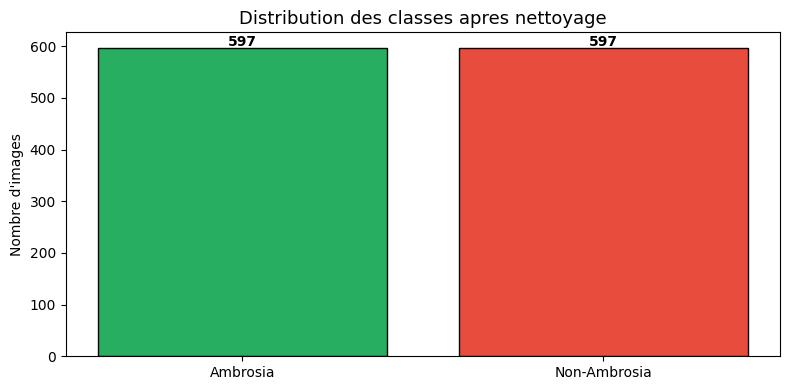

In [9]:
# 2c. Standardisation 224x224 RGB + Equilibrage
def standardize(paths: list, label: str) -> list:
    valid = []
    for path in tqdm(paths, desc=f'Standardisation {label}'):
        try:
            img = Image.open(path).convert('RGB')
            img = img.resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']), Image.LANCZOS)
            img.save(path, 'JPEG', quality=92)
            valid.append(path)
        except (OSError, IOError) as e:
            log.warning(f'Erreur {path}: {e}'); os.remove(path)
    return valid

kept_a  = standardize(kept_a,  'ambrosia')
kept_na = standardize(kept_na, 'non_ambrosia')

n_balanced = min(len(kept_a), len(kept_na), EFFECTIVE_TARGET)
log.info(f'Equilibrage -> {n_balanced} images par classe')

for label, paths in [('ambrosia', kept_a), ('non_ambrosia', kept_na)]:
    if len(paths) > n_balanced:
        to_remove = random.sample(paths, len(paths) - n_balanced)
        for p in to_remove:
            os.remove(p)

n_a_final  = len(os.listdir(os.path.join(CONFIG['RAW_DIR'], 'ambrosia')))
n_na_final = len(os.listdir(os.path.join(CONFIG['RAW_DIR'], 'non_ambrosia')))
log.info(f'Dataset final : {n_a_final} ambrosia | {n_na_final} non_ambrosia | total = {n_a_final + n_na_final}')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Ambrosia', 'Non-Ambrosia'], [n_a_final, n_na_final],
              color=['#27ae60', '#e74c3c'], edgecolor='black')
ax.set_title('Distribution des classes apres nettoyage', fontsize=13)
ax.set_ylabel("Nombre d'images")
for bar, n in zip(bars, [n_a_final, n_na_final]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(n), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_dataset.png', dpi=120, bbox_inches='tight')
plt.show()

## ✂️ PHASE 3 — Partitionnement Stratifié 70 / 20 / 10 (images originales)

Le partitionnement est effectué **avant toute augmentation**, sur les images
**originales uniquement**. C'est la garantie anti-fuite : une image originale et
ses futures variantes augmentées resteront toujours dans le **même** sous-ensemble.

- **Train (70 %)** : seul sous-ensemble qui sera ensuite augmenté (Phase 3b)
- **Validation (20 %)** : early stopping et sélection du meilleur modèle — **originaux seulement**
- **Test (10 %)** : évaluation finale, jamais vu pendant l'entraînement — **originaux seulement**

Le partitionnement est stratifié (proportions de classes identiques dans chaque split).

Copying files: 1194 files [00:00, 7137.32 files/s]


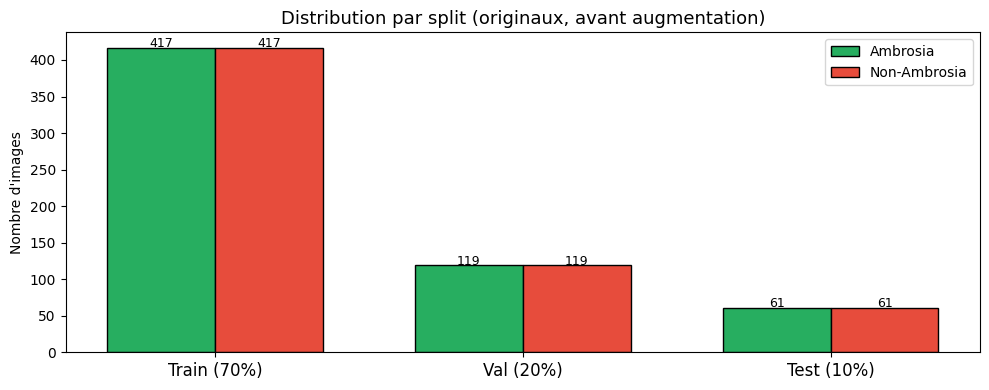

In [10]:
# 3. Partitionnement stratifié SUR IMAGES ORIGINALES (avant augmentation)
# RAW_DIR ne contient que des originaux à ce stade -> aucune fuite possible :
# une image et ses variantes (générées en Phase 3b) resteront dans le même split.
if os.path.exists(CONFIG['SPLIT_DIR']):
    shutil.rmtree(CONFIG['SPLIT_DIR'])

splitfolders.ratio(
    CONFIG['RAW_DIR'], output=CONFIG['SPLIT_DIR'],
    seed=42, ratio=(0.70, 0.20, 0.10), group_prefix=None
)

split_counts = {}
for split in ['train', 'val', 'test']:
    split_counts[split] = {}
    for label in ['ambrosia', 'non_ambrosia']:
        folder = os.path.join(CONFIG['SPLIT_DIR'], split, label)
        split_counts[split][label] = len(os.listdir(folder)) if os.path.exists(folder) else 0

log.info('Partitionnement (images originales) :')
log.info('  Split      | Ambrosia | Non-Ambrosia | Total')
log.info('  -----------|----------|--------------|------')
for s, c in split_counts.items():
    t = sum(c.values())
    log.info(f"  {s:10} | {c['ambrosia']:>8} | {c['non_ambrosia']:>12} | {t}")

fig, ax = plt.subplots(figsize=(10, 4))
splits = list(split_counts.keys())
x, w = np.arange(len(splits)), 0.35
bars_a  = [split_counts[s]['ambrosia']     for s in splits]
bars_na = [split_counts[s]['non_ambrosia'] for s in splits]
ax.bar(x - w/2, bars_a,  w, label='Ambrosia',     color='#27ae60', edgecolor='black')
ax.bar(x + w/2, bars_na, w, label='Non-Ambrosia', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Train (70%)', 'Val (20%)', 'Test (10%)'], fontsize=12)
ax.set_ylabel("Nombre d'images")
ax.set_title('Distribution par split (originaux, avant augmentation)', fontsize=13)
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Copie val/ et test/ vers Google Drive (originaux uniquement) ──────────────
log.info('Copie des splits val et test vers Google Drive...')

AUG_SUFFIXES = ('_flip', '_rot_p', '_rot_m', '_bright', '_zoom')

def purge_aug_variants(gdrive_dir):
    """Supprime d'éventuelles variantes augmentées laissées par d'anciennes
    exécutions, pour garantir que val/ et test/ sur Drive restent 100% originaux."""
    removed = 0
    for label in ['ambrosia', 'non_ambrosia']:
        d = os.path.join(gdrive_dir, label)
        if not os.path.exists(d):
            continue
        for fname in os.listdir(d):
            stem = os.path.splitext(fname)[0]
            if any(suf in stem for suf in AUG_SUFFIXES):
                try:
                    os.remove(os.path.join(d, fname)); removed += 1
                except Exception as e:
                    log.debug(f'Purge échouée {fname}: {e}')
    if removed:
        log.info(f'  🧹 {removed} variantes augmentées obsolètes purgées de {os.path.basename(gdrive_dir)}')

def copy_split_to_drive(split_name, gdrive_dir):
    """Copie data/split/<split_name>/<label>/*.jpg → Drive/<gdrive_dir>/<label>/."""
    purge_aug_variants(gdrive_dir)
    copied = 0
    src_root = os.path.join(CONFIG['SPLIT_DIR'], split_name)
    for label in ['ambrosia', 'non_ambrosia']:
        src_folder  = os.path.join(src_root, label)
        dest_folder = os.path.join(gdrive_dir, label)
        os.makedirs(dest_folder, exist_ok=True)
        if not os.path.exists(src_folder):
            continue
        for fname in os.listdir(src_folder):
            src_path  = os.path.join(src_folder, fname)
            dest_path = os.path.join(dest_folder, fname)
            if not os.path.exists(dest_path):
                try:
                    shutil.copy2(src_path, dest_path)
                    copied += 1
                except Exception as e:
                    log.debug(f'Copie échouée {fname}: {e}')
    return copied

n_val_copied  = copy_split_to_drive('val',  GDRIVE_SUBDIRS['photos_val'])
n_test_copied = copy_split_to_drive('test', GDRIVE_SUBDIRS['photos_test'])

log.info(f'  ✅ Photos_Val  : {n_val_copied} images copiées → {GDRIVE_SUBDIRS["photos_val"]}')
log.info(f'  ✅ Photos_Test : {n_test_copied} images copiées → {GDRIVE_SUBDIRS["photos_test"]}')
log.info(f'  Structure : ambrosia/ et non_ambrosia/ conservés dans chaque dossier Drive')
log.info('Phase 3 terminée (originaux partitionnés). -> Phase 3b (augmentation du train).')


## 🖼️ PHASE 3b — Augmentation Offline (train uniquement, ×6)

L'augmentation est appliquée **après** le partitionnement et **seulement** sur
`data/split/train/`. Les dossiers `val/` et `test/` ne sont **jamais** touchés :
ils restent 100 % originaux, ce qui élimine la fuite de données entre splits.

Chaque image originale du train génère 5 variantes `.jpg` :

| Transformation | Description |
|---|---|
| `_flip` | Miroir horizontal |
| `_rot_p` | Rotation +25° |
| `_rot_m` | Rotation -25° |
| `_bright` | Luminosité +40% |
| `_zoom` | Zoom central crop 80% |

> **Effet** : seules les images d'entraînement sont multipliées (×6). Le modèle
> est ainsi évalué sur des données strictement originales et indépendantes.

In [11]:
# 3b. AUGMENTATION OFFLINE — UNIQUEMENT sur le split d'entraînement (train/)
# Appliquée APRÈS le partitionnement : val/ et test/ ne contiennent que des
# images originales. Aucune variante d'une image de val/test ne peut "fuiter"
# vers le train, et inversement -> pas de fuite de données entre splits.

import os, random
import numpy as np
from PIL import Image, ImageEnhance
from pathlib import Path
from tqdm.auto import tqdm

log.info('=== PHASE 3b : Augmentation offline du TRAIN uniquement ===')

# ── Configuration ──────────────────────────────────────────────
AUG_SEED      = 42
ZOOM_FACTOR   = 0.80
ROTATION_DEG  = 25
BRIGHTNESS_F  = 1.40
random.seed(AUG_SEED)
np.random.seed(AUG_SEED)

# ── Transformations ────────────────────────────────────────────
def aug_flip(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT)

def aug_rotate(img, deg):
    return img.rotate(deg, resample=Image.BILINEAR, expand=False)

def aug_brightness(img, factor):
    return ImageEnhance.Brightness(img).enhance(factor)

def aug_zoom(img, factor):
    w, h = img.size
    cw, ch = int(w * factor), int(h * factor)
    l, t = (w - cw) // 2, (h - ch) // 2
    return img.crop((l, t, l + cw, t + ch)).resize((w, h), Image.BILINEAR)

TRANSFORMATIONS = {
    '_flip'   : lambda img: aug_flip(img),
    '_rot_p'  : lambda img: aug_rotate(img, ROTATION_DEG),
    '_rot_m'  : lambda img: aug_rotate(img, -ROTATION_DEG),
    '_bright' : lambda img: aug_brightness(img, BRIGHTNESS_F),
    '_zoom'   : lambda img: aug_zoom(img, ZOOM_FACTOR),
}

EXT          = {'.jpg', '.jpeg', '.png'}
aug_suffixes = set(TRANSFORMATIONS.keys())

# ── CIBLE : exclusivement data/split/train/ ────────────────────
TRAIN_DIR  = Path(CONFIG['SPLIT_DIR']) / 'train'
class_dirs = [d for d in TRAIN_DIR.iterdir()
              if d.is_dir() and not d.name.startswith('.')]
log.info(f"Dossier augmenté : {TRAIN_DIR}")
log.info(f"Classes (train) : {[d.name for d in class_dirs]}")

stats     = {}
total_new = 0

for class_dir in class_dirs:
    cls_name = class_dir.name

    # Images originales du train (sans suffixe d'augmentation)
    orig = [p for p in class_dir.glob('*')
            if p.suffix.lower() in EXT
            and not any(suf in p.stem for suf in aug_suffixes)]
    n_orig = len(orig)
    n_new  = 0

    for img_path in tqdm(orig, desc=f"Aug train {cls_name}", leave=False):
        try:
            img = Image.open(img_path).convert('RGB')
            for suffix, transform_fn in TRANSFORMATIONS.items():
                out = class_dir / (img_path.stem + suffix + '.jpg')
                if not out.exists():
                    transform_fn(img).convert('RGB').save(str(out), 'JPEG', quality=92)
                    n_new += 1
        except Exception as e:
            log.warning(f"    Erreur {img_path.name} : {e}")

    n_total = len([p for p in class_dir.glob('*') if p.suffix.lower() in EXT])
    stats[cls_name] = {'originales': n_orig, 'total': n_total}
    total_new += n_new
    log.info(f"  {cls_name} : {n_orig} -> {n_total} images (+{n_new})")

# ── Vérification anti-fuite : aucune variante augmentée dans val/ et test/ ─────
log.info('--- Contrôle anti-fuite : val/ et test/ doivent rester 100% originaux ---')
leak_total = 0
for split in ['val', 'test']:
    leak = 0
    sdir = Path(CONFIG['SPLIT_DIR']) / split
    if sdir.exists():
        for p in sdir.rglob('*'):
            if p.suffix.lower() in EXT and any(suf in p.stem for suf in aug_suffixes):
                leak += 1
    leak_total += leak
    log.info(f"  {split:5s} : {'OK (aucune variante)' if leak == 0 else f'⚠️ {leak} variante(s) détectée(s)'}")
if leak_total == 0:
    log.info('  ✅ Aucune fuite : seul le train est augmenté.')
else:
    log.warning('  ⚠️ Des variantes augmentées subsistent dans val/test — vérifier la pipeline.')

# ── Résumé ─────────────────────────────────────────────────────
log.info('=== Résumé Augmentation (train uniquement) ===')
for cls, s in stats.items():
    ratio = s['total'] / s['originales'] if s['originales'] > 0 else 0
    log.info(f"  {cls:20s} : {s['originales']:4d} -> {s['total']:5d} images  (x{ratio:.1f})")
log.info(f"  Total nouvelles images (train) : {total_new}")
log.info('Phase 3b terminée. val/ et test/ restent 100% originaux. -> Phase 4 (Entraînement).')


Aug train ambrosia:   0%|          | 0/417 [00:00<?, ?it/s]

Aug train non_ambrosia:   0%|          | 0/417 [00:00<?, ?it/s]

## 🏋️ PHASE 4 — Entraînement Transfer Learning (2 Phases)

L'entraînement se fait en **deux phases** avec le même modèle `yolo26n-cls.pt` :

| Phase | Backbone | Epochs | LR | Nouveautés v5.1 |
|---|---|---|---|---|
| **Phase 1** | Gelé (freeze=10) | 10 | 0.001 | Warmup 3 epochs |
| **Phase 2** | Dégelé | **80** | **5e-5** | Label smoothing 0.05, weight decay 5e-4, cosine LR, random erasing 0.2, scale 0.3 |

Ces ajustements visent à mieux régulariser le modèle sans changer son architecture,
pour atteindre F1 ≥ 0.90.

In [12]:
# 4a. PHASE 1 : Backbone gele (freeze=10)
# CORRECTION : suppression de flipud, degrees, translate, perspective, shear
# (augmentations de détection, non applicables ou warnings en classification)
log.info('PHASE 1 : Backbone gele (freeze=10)...')

# Disable Ultralytics MLflow autologging to prevent conflicts
from ultralytics import settings
settings.update({'mlflow': False})

model = YOLO(CONFIG['MODEL_NAME'])

with mlflow.start_run(run_name='training_phase1_v4', nested=True):
    mlflow.log_params({
        'phase': 1, 'epochs': CONFIG['PHASE1_EPOCHS'],
        'lr': CONFIG['PHASE1_LR'], 'freeze': CONFIG['PHASE1_FREEZE'],
        'model': CONFIG['MODEL_NAME'], 'img_size': CONFIG['IMG_SIZE'],
        'warmup_epochs': CONFIG['WARMUP_EPOCHS'],
    })
    results_p1 = model.train(
        data          = CONFIG['SPLIT_DIR'],
        epochs        = CONFIG['PHASE1_EPOCHS'],
        imgsz         = CONFIG['IMG_SIZE'],
        lr0           = CONFIG['PHASE1_LR'],
        freeze        = CONFIG['PHASE1_FREEZE'],
        mosaic        = CONFIG['AUGMENT_MOSAIC'],
        mixup         = CONFIG['AUGMENT_MIXUP'],
        fliplr        = CONFIG['AUGMENT_FLIPLR'],
        erasing       = CONFIG['AUGMENT_ERASING'],
        scale         = CONFIG['AUGMENT_SCALE'],
        hsv_h         = CONFIG['AUGMENT_HSV_H'],
        hsv_s         = CONFIG['AUGMENT_HSV_S'],
        hsv_v         = CONFIG['AUGMENT_HSV_V'],
        warmup_epochs = CONFIG['WARMUP_EPOCHS'],
        patience      = CONFIG['PATIENCE'],
        project       = CONFIG['RAW_DIR'],
        name          = 'phase1_frozen',
        exist_ok      = True
    )
    mlflow.log_metric('phase1_top1', float(results_p1.results_dict.get('metrics/accuracy_top1', 0)))

RUNTIME['phase1_save_dir'] = str(results_p1.save_dir)
PHASE1_BEST = os.path.join(RUNTIME['phase1_save_dir'], 'weights', 'best.pt')
log.info(f'Phase 1 terminee. Meilleur modele : {PHASE1_BEST}')


Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/split, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=phase1_frozen, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=25, perspecti

In [13]:
# 4b. PHASE 2 : Fine-tuning complet (v5.1 hyperparametres optimises)
# CORRECTION : suppression de copy_paste (augmentation de détection/segmentation,
# non applicable en classification — génère un warning Ultralytics)
log.info('PHASE 2 : Fine-tuning (v5.1: label_smoothing, weight_decay, cos_lr)...')
model = YOLO(PHASE1_BEST)

with mlflow.start_run(run_name='training_phase2_v4', nested=True):
    mlflow.log_params({
        'phase': 2, 'epochs': CONFIG['PHASE2_EPOCHS'],
        'lr': CONFIG['PHASE2_LR'], 'freeze': CONFIG['PHASE2_FREEZE'],
        'label_smoothing': CONFIG['LABEL_SMOOTHING'],
        'weight_decay': CONFIG['WEIGHT_DECAY'],
        'cos_lr': CONFIG['COS_LR'],
        'erasing': CONFIG['AUGMENT_ERASING'],
        'scale': CONFIG['AUGMENT_SCALE'],
    })
    results_p2 = model.train(
        data            = CONFIG['SPLIT_DIR'],
        epochs          = CONFIG['PHASE2_EPOCHS'],
        imgsz           = CONFIG['IMG_SIZE'],
        lr0             = CONFIG['PHASE2_LR'],
        freeze          = CONFIG['PHASE2_FREEZE'],
        label_smoothing = CONFIG['LABEL_SMOOTHING'],
        weight_decay    = CONFIG['WEIGHT_DECAY'],
        dropout         = CONFIG['DROPOUT'],
        warmup_epochs   = CONFIG['WARMUP_EPOCHS'],
        cos_lr          = CONFIG['COS_LR'],
        mosaic          = CONFIG['AUGMENT_MOSAIC'],
        mixup           = CONFIG['AUGMENT_MIXUP'],
        fliplr          = CONFIG['AUGMENT_FLIPLR'],
        erasing         = CONFIG['AUGMENT_ERASING'],
        scale           = CONFIG['AUGMENT_SCALE'],
        hsv_h           = CONFIG['AUGMENT_HSV_H'],
        hsv_s           = CONFIG['AUGMENT_HSV_S'],
        hsv_v           = CONFIG['AUGMENT_HSV_V'],
        # Note : flipud, degrees, translate, perspective, shear, copy_paste supprimés
        # (augmentations de détection/segmentation, ignorées ou warning en cls)
        patience        = CONFIG['PATIENCE'],
        project         = CONFIG['RAW_DIR'],
        name            = 'phase2_fine_tuned',
        exist_ok        = True
    )
    mlflow.log_metric('phase2_top1', float(results_p2.results_dict.get('metrics/accuracy_top1', 0)))

RUNTIME['phase2_save_dir'] = str(results_p2.save_dir)
BEST_MODEL = os.path.join(RUNTIME['phase2_save_dir'], 'weights', 'best.pt')
RUNTIME['best_model_path'] = BEST_MODEL
log.info(f'Phase 2 terminee. Meilleur modele final : {BEST_MODEL}')


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data/split, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/runs/classify/data/Herbe_a_poux/phase1_frozen/weights/best.pt, momentum=0.937, mosaic=0.5, multi_sca

## 📡 PHASE 5 — Validation en Temps Réel par Epoch

Lecture du fichier `results.csv` généré par YOLO pour tracer l'évolution des losses et de l'accuracy
epoch par epoch. Les chemins utilisent les répertoires `save_dir` réels (résolus dynamiquement).

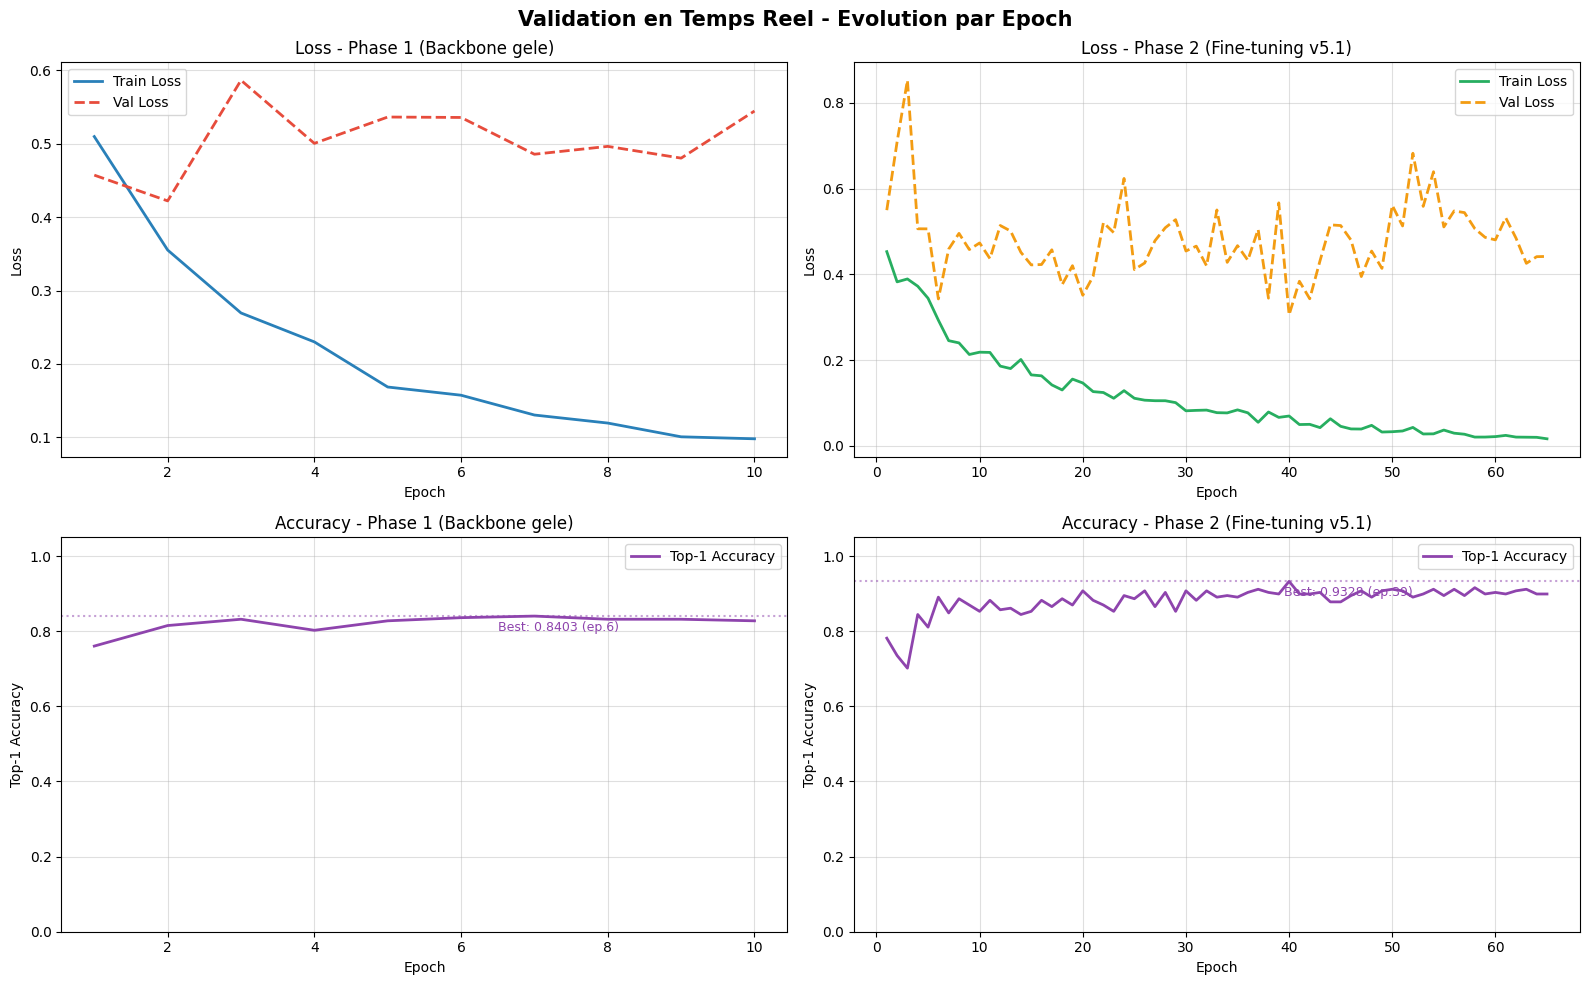

In [14]:
# 5. Validation en temps reel
def load_yolo_results(run_dir: str) -> Optional[pd.DataFrame]:
    csv_path = os.path.join(run_dir, 'results.csv')
    if not os.path.exists(csv_path):
        log.warning(f'Fichier introuvable : {csv_path}'); return None
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df

def find_column(df: pd.DataFrame, keywords: list) -> Optional[str]:
    for col in df.columns:
        if all(kw in col.lower() for kw in keywords):
            return col
    return None

def plot_realtime_validation(df_p1, df_p2):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Validation en Temps Reel - Evolution par Epoch', fontsize=15, fontweight='bold')
    for col_idx, (df, name, ct, cv) in enumerate([
        (df_p1, 'Phase 1 (Backbone gele)',  '#2980b9', '#e74c3c'),
        (df_p2, 'Phase 2 (Fine-tuning v5.1)', '#27ae60', '#f39c12'),
    ]):
        if df is None:
            axes[0, col_idx].text(0.5, 0.5, 'Indisponible', ha='center', va='center')
            axes[0, col_idx].axis('off'); axes[1, col_idx].axis('off'); continue
        epochs = df.get('epoch', pd.Series(range(len(df))))
        tl = find_column(df, ['train', 'loss'])
        vl = find_column(df, ['val', 'loss'])
        ac = find_column(df, ['accuracy']) or find_column(df, ['acc'])
        ax_l = axes[0, col_idx]
        if tl: ax_l.plot(epochs, df[tl], label='Train Loss', color=ct, lw=2)
        if vl: ax_l.plot(epochs, df[vl], label='Val Loss', color=cv, lw=2, ls='--')
        ax_l.set_title(f'Loss - {name}'); ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Loss')
        ax_l.legend(); ax_l.grid(True, alpha=0.4)
        ax_a = axes[1, col_idx]
        if ac:
            ax_a.plot(epochs, df[ac], label='Top-1 Accuracy', color='#8e44ad', lw=2)
            best = df[ac].max(); bep = df[ac].idxmax()
            ax_a.axhline(best, color='#8e44ad', ls=':', alpha=0.5)
            ax_a.annotate(f'Best: {best:.4f} (ep.{bep})', xy=(bep, best),
                          xytext=(bep+0.5, best-0.04), fontsize=9, color='#8e44ad')
        ax_a.set_title(f'Accuracy - {name}'); ax_a.set_xlabel('Epoch')
        ax_a.set_ylabel('Top-1 Accuracy'); ax_a.set_ylim(0, 1.05)
        ax_a.legend(); ax_a.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig('validation_realtime.png', dpi=150, bbox_inches='tight')
    plt.show()

df_p1 = load_yolo_results(RUNTIME['phase1_save_dir'])
df_p2 = load_yolo_results(RUNTIME['phase2_save_dir'])
plot_realtime_validation(df_p1, df_p2)

## 📊 PHASE 6 — Diagnostic Automatique des Courbes

Le diagnostic analyse les derniers 20 % des epochs pour détecter automatiquement :

| Diagnostic | Signal | Actions correctives |
|---|---|---|
| 🔴 **Overfitting** | `val_loss` remonte tandis que `train_loss` baisse | + régularisation, + données |
| 🟡 **Underfitting** | Les deux losses restent élevées | + epochs, + LR |
| 🟠 **Instable** | Forte variance de la val_loss | ↓ LR, ↑ batch_size |
| 🟢 **Idéal** | Convergence des deux courbes | Sauvegarder et évaluer |

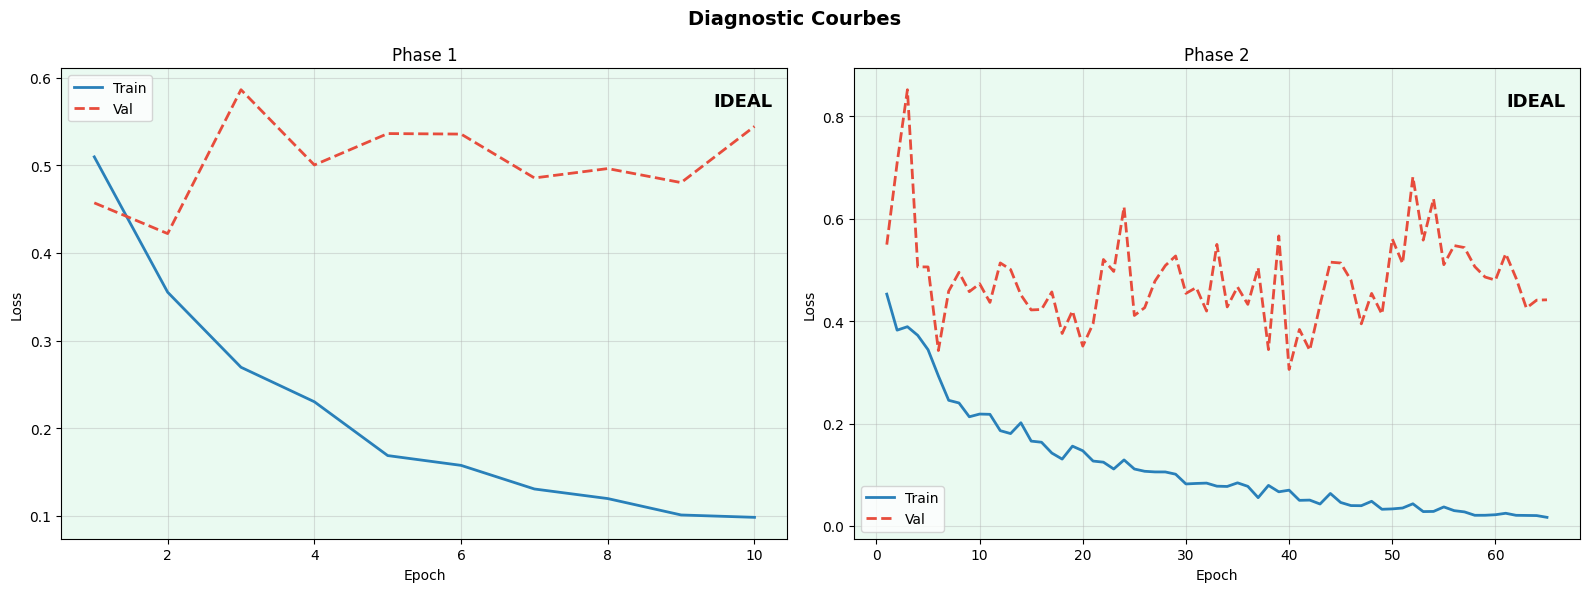

In [15]:
# 6. Diagnostic automatique
def diagnose_curves(df, phase_name):
    if df is None or len(df) < 5:
        log.warning(f'{phase_name}: donnees insuffisantes'); return 'unknown'
    tl_col = find_column(df, ['train', 'loss'])
    vl_col = find_column(df, ['val', 'loss'])
    if not tl_col or not vl_col:
        log.warning(f'{phase_name}: colonnes loss introuvables'); return 'unknown'
    tl, vl = df[tl_col].values, df[vl_col].values
    n = max(3, len(tl) // 5)
    tl_end, tl_beg = tl[-n:].mean(), tl[:n].mean()
    vl_end, vl_beg = vl[-n:].mean(), vl[:n].mean()
    vl_trend = vl[-1] - vl[-n]
    vl_std = np.std(np.diff(vl[-n:]))
    gap = vl_end - tl_end

    if vl_trend > 0.05 and tl_end < tl_beg * 0.8:
        status, badge = 'overfitting', 'OVERFITTING'
    elif tl_end > tl_beg * 0.85 and vl_end > vl_beg * 0.85:
        status, badge = 'underfitting', 'UNDERFITTING'
    elif vl_std > 0.08:
        status, badge = 'instable', 'INSTABLE'
    else:
        status, badge = 'ideal', 'IDEAL'
    log.info(f'  {phase_name}: [{badge}] train_loss={tl_end:.4f} val_loss={vl_end:.4f} gap={gap:.4f} trend={vl_trend:.4f}')
    return status

def plot_diagnosis_dashboard(df_p1, df_p2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Diagnostic Courbes', fontsize=14, fontweight='bold')
    for ax, df, title in [(axes[0], df_p1, 'Phase 1'), (axes[1], df_p2, 'Phase 2')]:
        if df is None: ax.text(0.5, 0.5, 'N/A', ha='center', va='center'); ax.axis('off'); continue
        tl_col, vl_col = find_column(df, ['train','loss']), find_column(df, ['val','loss'])
        epochs = df.get('epoch', pd.Series(range(len(df))))
        if tl_col: ax.plot(epochs, df[tl_col], label='Train', color='#2980b9', lw=2)
        if vl_col: ax.plot(epochs, df[vl_col], label='Val', color='#e74c3c', lw=2, ls='--')
        if tl_col and vl_col:
            tl, vl = df[tl_col].values, df[vl_col].values
            n_end = max(3, len(tl)//5)
            vt = vl[-1]-vl[-n_end]; te,tb = tl[-n_end:].mean(), tl[:n_end].mean()
            vs = np.std(np.diff(vl[-n_end:]))
            if vt>0.05 and te<tb*0.8: d,bg='OVERFIT','#fdecea'
            elif te>tb*0.85: d,bg='UNDERFIT','#fef9e7'
            elif vs>0.08: d,bg='INSTABLE','#fff3e0'
            else: d,bg='IDEAL','#eafaf1'
            ax.set_facecolor(bg)
            ax.text(0.98,0.95,d,transform=ax.transAxes,ha='right',va='top',fontsize=13,fontweight='bold')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(); ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig('diagnostic_courbes.png', dpi=150, bbox_inches='tight')
    plt.show()

log.info('=== DIAGNOSTIC DES COURBES ===')
status_p1 = diagnose_curves(df_p1, 'Phase 1')
status_p2 = diagnose_curves(df_p2, 'Phase 2')
plot_diagnosis_dashboard(df_p1, df_p2)

## 📈 PHASE 7 — Métriques Quantitatives

Toutes les métriques sont calculées **dans la même cellule** :

- **Top-1 Accuracy** : la classe la plus probable est-elle correcte ?
- **Top-5 Accuracy** : la classe correcte est-elle dans les 5 premières ? (pertinent si extension multi-classes)
- **F1-Macro** : métrique cible principale (≥ 0.90)
- **F1-Binaire**, Précision, Rappel, Kappa de Cohen, ROC-AUC, PR-AUC


Inference test:   0%|          | 0/122 [00:00<?, ?it/s]

  METRIQUES QUANTITATIVES v5.1 — JEU DE TEST (avec IC 95%)
  Top-1 Accuracy      : 0.8525  [0.7869, 0.9098]
  Top-5 Accuracy      : 1.0000  [1.0000, 1.0000]
  Balanced Acc.       : 0.8525  [0.7871, 0.9108]
  F1-Macro            : 0.8524  [0.7864, 0.9098] <<< CIBLE
  F1-Binaire          : 0.8548  [0.7796, 0.9153]
  Precision           : 0.8413  [0.7499, 0.9298]
  Rappel              : 0.8689  [0.7794, 0.9394]
  Kappa Cohen         : 0.7049  [0.5728, 0.8197]
  ROC-AUC             : 0.9336  [0.8855, 0.9707]
  PR-AUC              : 0.9366  [0.8838, 0.9755]

              precision    recall  f1-score   support

    ambrosia     0.8413    0.8689    0.8548        61
non_ambrosia     0.8644    0.8361    0.8500        61

    accuracy                         0.8525       122
   macro avg     0.8528    0.8525    0.8524       122
weighted avg     0.8528    0.8525    0.8524       122



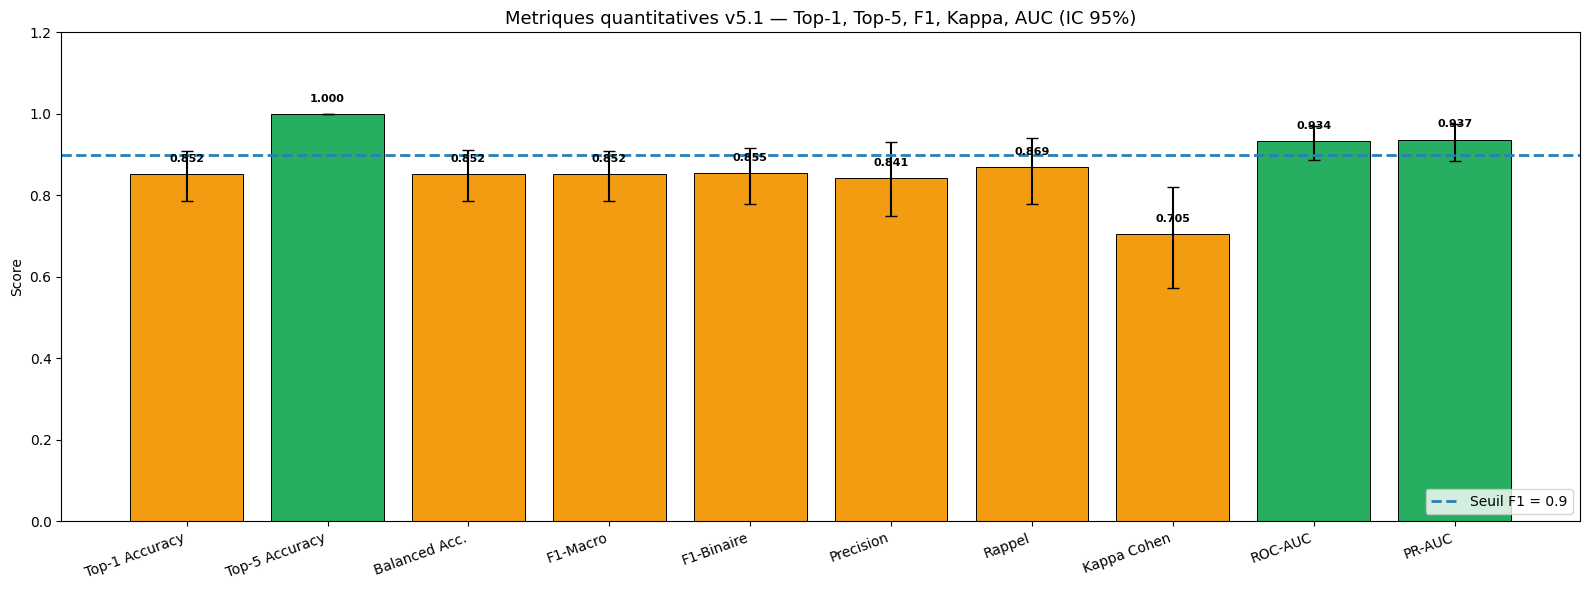

In [16]:
# 7. Inference + Top-1 Accuracy + Top-5 Accuracy + F1 + toutes metriques
# === 7a. Inference sur le jeu de test ===
if not os.path.exists(BEST_MODEL):
    raise FileNotFoundError(f'Modele introuvable : {BEST_MODEL}')

model_eval   = YOLO(BEST_MODEL)
class_names  = list(model_eval.names.values())
label_to_idx = {v: k for k, v in model_eval.names.items()}
n_classes    = len(class_names)
ambrosia_idx = class_names.index('ambrosia') if 'ambrosia' in class_names else 0
log.info(f'Classes ({n_classes}) : {class_names}')

test_images = sorted(glob.glob(os.path.join(CONFIG['SPLIT_DIR'], 'test', '*', '*.jpg')))
log.info(f'Images de test : {len(test_images)}')

y_true, y_pred, y_scores, valid_paths = [], [], [], []
top1_correct, top5_correct, total_eval = 0, 0, 0

for img_path in tqdm(test_images, desc='Inference test'):
    folder_name = os.path.basename(os.path.dirname(img_path))
    if folder_name not in label_to_idx:
        continue
    true_idx = label_to_idx[folder_name]
    try:
        result = model_eval(img_path, verbose=False)[0]
        probs  = result.probs.data.cpu().numpy()
        pred_idx = int(np.argmax(probs))
    except Exception as e:
        log.warning(f'Erreur inference {img_path}: {e}'); continue

    y_true.append(true_idx)
    y_pred.append(pred_idx)
    y_scores.append(probs)
    valid_paths.append(img_path)

    # Top-1
    total_eval += 1
    if pred_idx == true_idx:
        top1_correct += 1
    # Top-5
    top5_indices = np.argsort(probs)[::-1][:min(5, n_classes)]
    if true_idx in top5_indices:
        top5_correct += 1

y_true   = np.array(y_true)
y_pred   = np.array(y_pred)
y_scores = np.array(y_scores)

top1_acc = top1_correct / total_eval if total_eval > 0 else 0.0
top5_acc = top5_correct / total_eval if total_eval > 0 else 0.0
log.info(f'Inference terminee : {total_eval} images')
log.info(f'Top-1 Accuracy : {top1_acc:.4f} ({top1_acc*100:.2f}%)')
log.info(f'Top-5 Accuracy : {top5_acc:.4f} ({top5_acc*100:.2f}%)')

# === 7b. Metriques sklearn ===
acc      = accuracy_score(y_true, y_pred)
bal_acc  = balanced_accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_bin   = f1_score(y_true, y_pred, pos_label=ambrosia_idx, average='binary')
prec     = precision_score(y_true, y_pred, pos_label=ambrosia_idx, average='binary', zero_division=0)
rec      = recall_score(y_true, y_pred, pos_label=ambrosia_idx, average='binary', zero_division=0)
kappa    = cohen_kappa_score(y_true, y_pred)

try:
    y_scr_amb = y_scores[:, ambrosia_idx]
    roc_auc   = roc_auc_score(y_true == ambrosia_idx, y_scr_amb)
    pr_p, pr_r, _ = precision_recall_curve(y_true == ambrosia_idx, y_scr_amb)
    pr_auc    = auc(pr_r, pr_p)
except Exception as e:
    roc_auc, pr_auc = 0.0, 0.0
    log.warning(f'AUC non calculable : {e}')

metrics_dict = {
    'Top-1 Accuracy': top1_acc,
    'Top-5 Accuracy': top5_acc,
    'Balanced Acc.'  : bal_acc,
    'F1-Macro'       : f1_macro,
    'F1-Binaire'     : f1_bin,
    'Precision'      : prec,
    'Rappel'         : rec,
    'Kappa Cohen'    : kappa,
    'ROC-AUC'        : roc_auc,
    'PR-AUC'         : pr_auc,
}

# === 7c. Bootstrap IC 95% ===
def bootstrap_ci(y_true, y_pred, y_scores, metric_fn, n_boot=1000, ci=0.95):
    n = len(y_true)
    scores = []
    rng = np.random.RandomState(42)
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        try:
            s = metric_fn(y_true[idx], y_pred[idx], y_scores[idx] if y_scores is not None else None)
            scores.append(s)
        except (ValueError, ZeroDivisionError):
            continue
    if not scores:
        return (0.0, 0.0)
    alpha = (1 - ci) / 2
    return (np.percentile(scores, alpha*100), np.percentile(scores, (1-alpha)*100))

log.info(f'Bootstrap IC 95% ({CONFIG["BOOTSTRAP_N"]} iterations)...')

def _top1(yt, yp, _): return accuracy_score(yt, yp)
def _top5(yt, yp, ys):
    if ys is None: return 0.0
    c = 0
    for i in range(len(yt)):
        t5 = np.argsort(ys[i])[::-1][:min(5, n_classes)]
        if yt[i] in t5: c += 1
    return c / len(yt)

metric_fns = {
    'Top-1 Accuracy': _top1,
    'Top-5 Accuracy': _top5,
    'Balanced Acc.':  lambda yt,yp,_: balanced_accuracy_score(yt,yp),
    'F1-Macro':       lambda yt,yp,_: f1_score(yt,yp,average='macro'),
    'F1-Binaire':     lambda yt,yp,_: f1_score(yt,yp,pos_label=ambrosia_idx,average='binary'),
    'Precision':      lambda yt,yp,_: precision_score(yt,yp,pos_label=ambrosia_idx,average='binary',zero_division=0),
    'Rappel':         lambda yt,yp,_: recall_score(yt,yp,pos_label=ambrosia_idx,average='binary',zero_division=0),
    'Kappa Cohen':    lambda yt,yp,_: cohen_kappa_score(yt,yp),
    'ROC-AUC':        lambda yt,yp,ys: roc_auc_score(yt==ambrosia_idx, ys[:,ambrosia_idx]) if ys is not None else 0,
    'PR-AUC':         lambda yt,yp,ys: auc(*precision_recall_curve(yt==ambrosia_idx, ys[:,ambrosia_idx])[:2][::-1]) if ys is not None else 0,
}

ci_metrics = {}
for name, fn in metric_fns.items():
    ci_metrics[name] = bootstrap_ci(y_true, y_pred, y_scores, fn, n_boot=CONFIG['BOOTSTRAP_N'])

# === 7d. Affichage ===
print('=' * 75)
print('  METRIQUES QUANTITATIVES v5.1 — JEU DE TEST (avec IC 95%)')
print('=' * 75)
for name, val in metrics_dict.items():
    ci_lo, ci_hi = ci_metrics.get(name, (0, 0))
    marker = ' <<< CIBLE' if name == 'F1-Macro' else ''
    print(f'  {name:20s}: {val:.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]{marker}')
print('=' * 75)
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# === 7e. MLflow ===
with mlflow.start_run(run_name='evaluation_test_v4', nested=True):
    for name, val in metrics_dict.items():
        key = name.replace(' ','_').replace('.','').replace('-','_')
        mlflow.log_metric(key, val)
        ci_lo, ci_hi = ci_metrics[name]
        mlflow.log_metric(f'{key}_ci_low', ci_lo)
        mlflow.log_metric(f'{key}_ci_high', ci_hi)

# === 7f. Visualisation avec barres d'erreur ===
fig, ax = plt.subplots(figsize=(16, 6))
names_m  = list(metrics_dict.keys())
values_m = list(metrics_dict.values())
colors_m = ['#27ae60' if v >= 0.90 else '#e74c3c' if v < 0.70 else '#f39c12' for v in values_m]
yerr_low  = [max(0, v - ci_metrics[n][0]) for n, v in zip(names_m, values_m)]
yerr_high = [max(0, ci_metrics[n][1] - v) for n, v in zip(names_m, values_m)]

bars = ax.bar(names_m, values_m, color=colors_m, edgecolor='black', linewidth=0.7,
              yerr=[yerr_low, yerr_high], capsize=4, error_kw={'lw':1.5, 'color':'#2c3e50'})
ax.axhline(CONFIG['F1_THRESHOLD'], color='#2980b9', ls='--', lw=2,
           label=f"Seuil F1 = {CONFIG['F1_THRESHOLD']}")
ax.set_ylim(0, 1.20)
ax.set_title('Metriques quantitatives v5.1 — Top-1, Top-5, F1, Kappa, AUC (IC 95%)', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
for bar, val in zip(bars, values_m):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('metriques_quantitatives_v5.png', dpi=150, bbox_inches='tight')
plt.show()

# === 7g. Export CSV ===
rows = []
for name, val in metrics_dict.items():
    ci_lo, ci_hi = ci_metrics[name]
    rows.append({'Metrique': name, 'Valeur': round(val,4), 'IC_95_low': round(ci_lo,4), 'IC_95_high': round(ci_hi,4)})
pd.DataFrame(rows).to_csv('metriques_test_v5.csv', index=False)
log.info('Metriques exportees : metriques_test_v5.csv')

## 🔬 PHASE 8 — Analyse Qualitative

### 8a · Matrice de Confusion
### 8b · Courbes ROC & Précision-Rappel
### 8c · Visualisation des erreurs (Faux Positifs / Faux Négatifs)
### 8d · Grad-CAM — Explicabilité visuelle
### 8e · 🗺️ Carte géographique des observations du test

La carte (Phase 8e) affiche la localisation GPS de chaque observation du jeu de test,
colorée selon sa classe réelle (vert = Ambrosia, rouge = Non-Ambrosia), permettant
de vérifier la couverture géographique et d'identifier d'éventuels biais spatiaux.

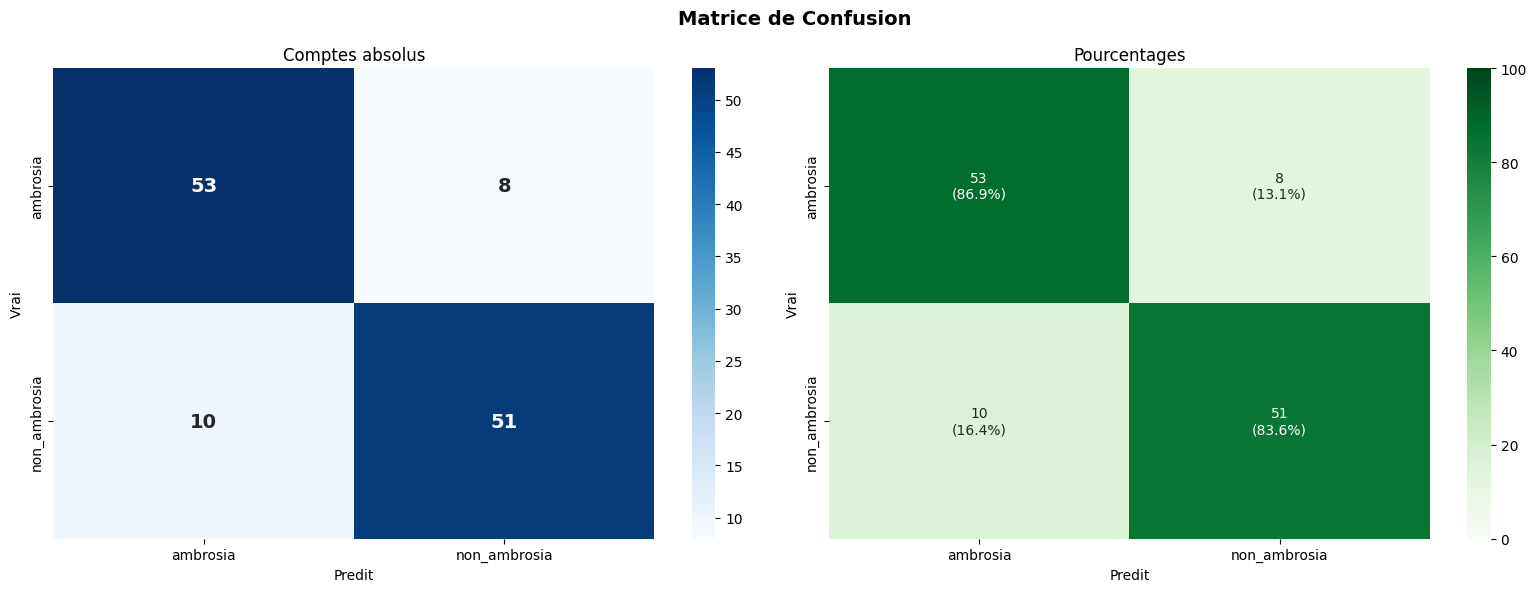

In [17]:
# 8a. Matrice de confusion
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrice de Confusion', fontsize=14, fontweight='bold')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size':14,'weight':'bold'}, ax=axes[0])
axes[0].set_title('Comptes absolus'); axes[0].set_ylabel('Vrai'); axes[0].set_xlabel('Predit')

annot_pct = [[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(len(class_names))]
             for i in range(len(class_names))]
sns.heatmap(cm_pct, annot=annot_pct, fmt='', cmap='Greens', cbar=True,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size':10}, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title('Pourcentages'); axes[1].set_ylabel('Vrai'); axes[1].set_xlabel('Predit')

if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    log.info(f'TP={tp} TN={tn} FP={fp} FN={fn} | Sens.={tp/(tp+fn):.4f} Spec.={tn/(tn+fp):.4f}')
plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

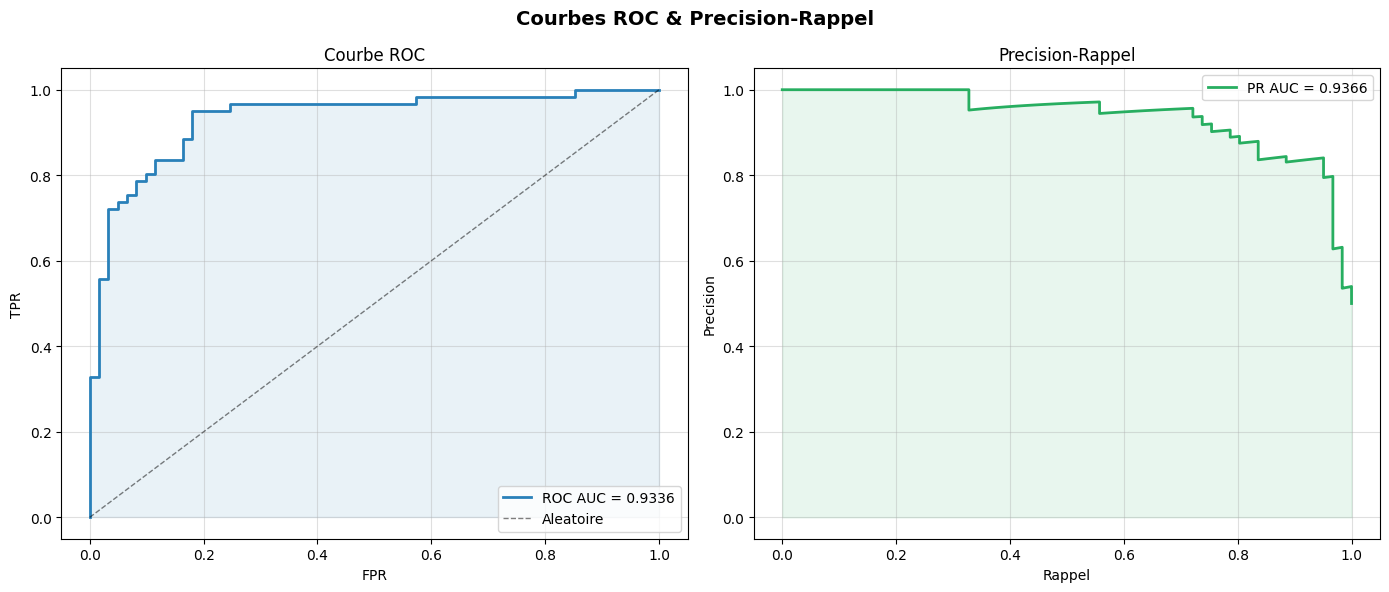

In [18]:
# 8b. Courbes ROC et Precision-Rappel
y_binary = (y_true == ambrosia_idx).astype(int)
y_scr_b  = y_scores[:, ambrosia_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Courbes ROC & Precision-Rappel', fontsize=14, fontweight='bold')

fpr, tpr, _ = roc_curve(y_binary, y_scr_b)
axes[0].plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Aleatoire')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[0].set_title('Courbe ROC'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.4)

pr_p_c, pr_r_c, _ = precision_recall_curve(y_binary, y_scr_b)
axes[1].plot(pr_r_c, pr_p_c, color='#27ae60', lw=2, label=f'PR AUC = {pr_auc:.4f}')
axes[1].fill_between(pr_r_c, pr_p_c, alpha=0.1, color='#27ae60')
axes[1].set_title('Precision-Rappel'); axes[1].set_xlabel('Rappel'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('courbes_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

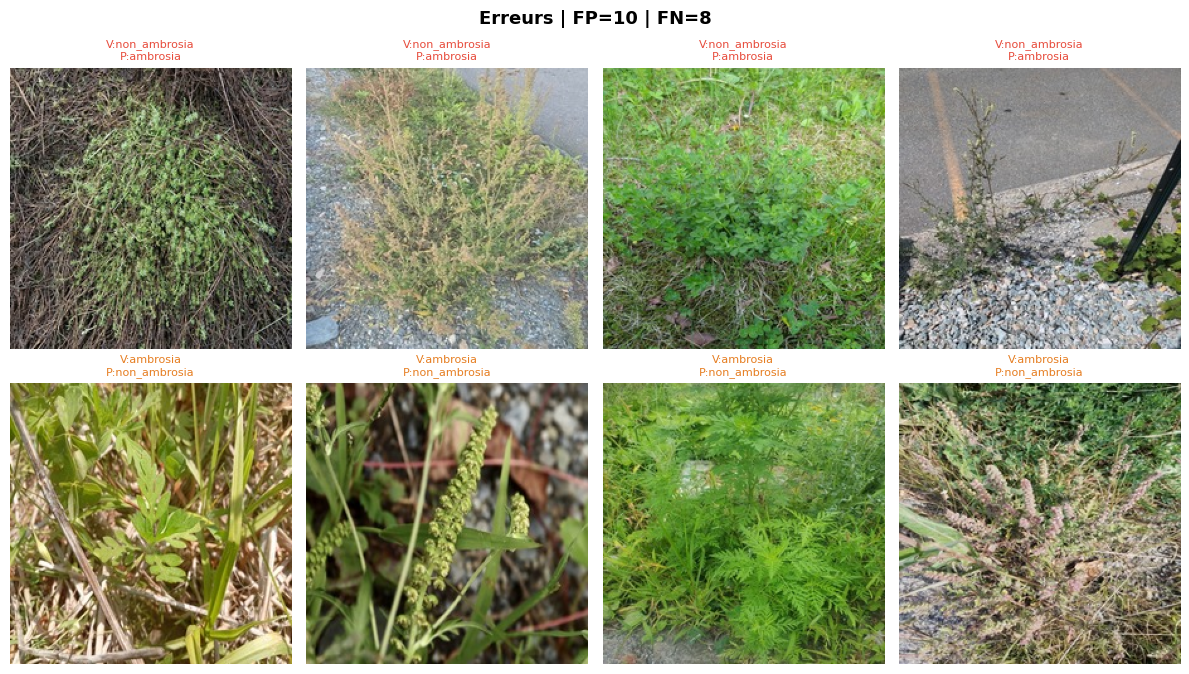

In [19]:
# 8c. Visualisation des erreurs (FP et FN)
fp_list, fn_list = [], []
for i, img_path in enumerate(valid_paths):
    if i >= len(y_true): break
    tl, pl = y_true[i], y_pred[i]
    if pl == ambrosia_idx and tl != ambrosia_idx:
        fp_list.append((img_path, class_names[tl], class_names[pl]))
    elif tl == ambrosia_idx and pl != ambrosia_idx:
        fn_list.append((img_path, class_names[tl], class_names[pl]))

log.info(f'Erreurs : {len(fp_list)} FP, {len(fn_list)} FN')
n_show = min(4, max(len(fp_list), len(fn_list), 1))
n_cols = max(n_show, 1)
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols*3, 7))
if n_cols == 1: axes = axes.reshape(2, 1)
fig.suptitle(f'Erreurs | FP={len(fp_list)} | FN={len(fn_list)}', fontsize=13, fontweight='bold')

for row, (err, lbl, clr) in enumerate([
    (fp_list[:n_show], 'FP', '#e74c3c'), (fn_list[:n_show], 'FN', '#e67e22')]):
    for col in range(n_cols):
        ax = axes[row, col]
        if col < len(err):
            p, tl_n, pl_n = err[col]
            try: ax.imshow(Image.open(p).resize((224,224))); ax.set_title(f'V:{tl_n}\nP:{pl_n}', fontsize=8, color=clr)
            except: ax.text(0.5,0.5,'Erreur',ha='center',va='center')
        ax.axis('off')
plt.tight_layout()
plt.savefig('erreurs_modele.png', dpi=120, bbox_inches='tight')
plt.show()

In [20]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  8d · Grad-CAM v5.1 — Fix définitif pour YOLOv26n-cls          ║
# ║                                                                  ║
# ║  Corrections vs v5.1 :                                          ║
# ║  1. Cible = model.10.conv (out_ch=1280) — dernière Conv avant   ║
# ║     le pooling global, identifiée par le diagnostic             ║
# ║  2. Forward sur backbone UNIQUEMENT (model.model[:-1])          ║
# ║     → évite le tuple retourné par la tête Classify              ║
# ║  3. SiLU inplace désactivé ciblé sur model.0.act uniquement     ║
# ║  4. Gradient capturé sur les feature maps backbone directement  ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, traceback
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Constantes ──────────────────────────────────────────────────────
TEST_DIR     = os.path.join(CONFIG['SPLIT_DIR'], 'test')
IMG_SIZE     = CONFIG['IMG_SIZE']
N_PAR_CLASSE = 4

print("=" * 60)
print("  8d · Grad-CAM v5.1 — Fix YOLOv26n-cls")
print("=" * 60)

# ── Vérifier / recharger model_eval ─────────────────────────────────
try:
    _ = model_eval
    print(f"✅  model_eval chargé")
except NameError:
    print("⚠️  Rechargement model_eval...")
    model_eval   = YOLO(BEST_MODEL)
    class_names  = list(model_eval.names.values())
    ambrosia_idx = class_names.index('ambrosia') if 'ambrosia' in class_names else 0

print(f"📁  TEST_DIR : {TEST_DIR}")
print()


# ── Classe GradCAM v5.1 ─────────────────────────────────────────────
class GradCAM:
    """
    Grad-CAM adapté à YOLOv26n-cls fusionné.

    Architecture YOLOv26n-cls identifiée par diagnostic :
      model.model[0..9]  → backbone (Conv, C2f, C3k2, PSA...)
      model.model[10]    → Classify (conv 1x1→1280, pool, drop, linear)
                           retourne un TUPLE → ne pas inclure dans le forward

    Stratégie :
      - Hooker model.10.conv.conv (la Conv2d 1x1→1280 dans Classify)
      - Faire passer l'image dans model.model[0..9] + model.10.conv
      - Puis pooling → linear manuellement pour obtenir les logits
      - Backward sur les logits → gradients sur model.10.conv.conv
    """

    def __init__(self, yolo_model):
        self.full_model = yolo_model.model
        self.full_model.eval()

        # Désactiver SiLU inplace (model.0.act identifié par diagnostic)
        n_fixed = 0
        for m in self.full_model.modules():
            if hasattr(m, 'inplace') and m.inplace:
                m.inplace = False
                n_fixed += 1
        print(f"   ✅ {n_fixed} activation(s) inplace désactivée(s)")

        # Identifier les sous-modules clés
        # model.model est une Sequential de 11 modules (0..10)
        layers       = list(self.full_model.model.children())
        self.backbone = nn.Sequential(*layers[:-1])  # modules 0..9
        self.head     = layers[-1]                   # module 10 (Classify)

        # Dans la tête Classify : conv, pool, drop, linear
        # On a besoin de : conv (ConvBNAct 1→1280), pool, drop, linear
        self.head_conv   = self.head.conv    # ConvBNAct wrapper
        self.head_pool   = self.head.pool    # AdaptiveAvgPool2d
        self.head_drop   = self.head.drop    # Dropout
        self.head_linear = self.head.linear  # Linear(1280, n_classes)

        # Cibler la Conv2d DANS head.conv (le .conv de ConvBNAct)
        # C'est model.10.conv.conv dans la liste nommée
        self.target_conv = self.head_conv.conv  # nn.Conv2d out_ch=1280
        print(f"   Cible Grad-CAM : head.conv.conv "
              f"(out_ch={self.target_conv.out_channels})")

        # Buffers
        self.activations = None
        self.gradients   = None

        # Hooks
        self._h1 = self.target_conv.register_forward_hook(
            lambda m, inp, out: setattr(self, 'activations', out.detach().clone())
        )
        self._h2 = self.target_conv.register_full_backward_hook(
            lambda m, g_in, g_out: setattr(
                self, 'gradients',
                g_out[0].detach().clone() if g_out[0] is not None else None
            )
        )
        print("   Hooks enregistrés ✅")

    def generate(self, img_path, class_idx=None):
        """Retourne (cam [H,W] normalisée, img_np [H,W,3] float32)."""

        # Préparation image
        pil    = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_np = np.array(pil, dtype=np.float32) / 255.0
        t      = torch.from_numpy(img_np.transpose(2, 0, 1)).unsqueeze(0)

        device = next(self.full_model.parameters()).device
        t = t.to(device)

        # Reset buffers
        self.activations = None
        self.gradients   = None

        with torch.enable_grad():
            t = t.detach().requires_grad_(True)

            # ── Forward backbone (modules 0..9) ──────────────────────
            feat = t
            for layer in self.backbone:
                feat = layer(feat)
            # feat : [1, C_backbone, H', W']

            # ── Forward tête manuellement ─────────────────────────────
            # head_conv = ConvBNAct : conv → bn → act
            # Le hook capte la Conv2d interne (avant BN/act)
            x    = self.head_conv(feat)      # → [1, 1280, H', W']
            x    = self.head_pool(x)         # → [1, 1280, 1, 1]
            x    = self.head_drop(x)
            logits = self.head_linear(x.flatten(1))  # → [1, n_classes]

            if class_idx is None:
                class_idx = int(logits.argmax().item())

            # ── Backward ─────────────────────────────────────────────
            self.full_model.zero_grad()
            one_hot = torch.zeros_like(logits)
            one_hot[0, class_idx] = 1.0
            logits.backward(gradient=one_hot)

        # ── Vérification ──────────────────────────────────────────────
        if self.activations is None:
            print("   ⚠️  activations=None — hook forward non déclenché")
            return None, img_np
        if self.gradients is None:
            print("   ⚠️  gradients=None — hook backward non déclenché")
            return None, img_np

        # ── Calcul CAM ────────────────────────────────────────────────
        # Poids = moyenne des gradients sur H,W pour chaque canal
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # [1, C, 1, 1]
        cam     = (weights * self.activations).sum(dim=1)         # [1, H', W']
        cam     = F.relu(cam).squeeze().cpu().numpy()             # [H', W']

        # Resize 224×224
        if cam.ndim < 2 or cam.size == 0:
            return None, img_np
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

        # Normalisation [0, 1]
        lo, hi = cam.min(), cam.max()
        if hi - lo > 1e-8:
            cam = (cam - lo) / (hi - lo)
        else:
            # CAM plate → afficher quand même (tout à 0)
            cam = np.zeros_like(cam)

        return cam, img_np

    def overlay(self, cam, img_np, alpha=0.5):
        hm = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        return np.clip(alpha * img_np + alpha * hm, 0, 1)

    def remove_hooks(self):
        self._h1.remove()
        self._h2.remove()
        print("   Hooks supprimés ✅")


# ── Collecte images de test ─────────────────────────────────────────
def collect_test_samples(test_dir, labels, n=4):
    samples = []
    for lbl in labels:
        folder = os.path.join(test_dir, lbl)
        if not os.path.exists(folder):
            print(f"   ⚠️  Dossier absent : {folder}")
            continue
        imgs = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for fname in imgs[:n]:
            samples.append((os.path.join(folder, fname), lbl))
    return samples


# ── Exécution principale ─────────────────────────────────────────────
try:
    gradcam = GradCAM(model_eval)
    samples = collect_test_samples(
        TEST_DIR, ['ambrosia', 'non_ambrosia'], n=N_PAR_CLASSE
    )

    if not samples:
        print(f"❌  Aucune image dans {TEST_DIR}")
    else:
        print(f"\n📸  {len(samples)} images à traiter...\n")
        nr   = len(samples)
        fig, axes = plt.subplots(nr, 3, figsize=(13, nr * 3.3))
        if nr == 1:
            axes = axes.reshape(1, 3)

        fig.suptitle(
            "Grad-CAM — Zones d'attention YOLOv26n-cls",
            fontsize=14, fontweight='bold', y=1.005
        )
        for ci, ct in enumerate(['Image originale', 'Carte Grad-CAM', 'Superposition']):
            axes[0, ci].set_title(ct, fontsize=10, fontweight='bold', pad=8)

        n_ok = 0
        for ri, (img_path, true_label) in enumerate(samples):

            # Inférence YOLO standard
            try:
                res      = model_eval(img_path, verbose=False)[0]
                pred_idx = int(res.probs.top1)
                conf     = float(res.probs.top1conf)
                pred_lbl = class_names[pred_idx]
            except Exception as e:
                print(f"  ⚠️  Inférence {os.path.basename(img_path)}: {e}")
                for ax in axes[ri]: ax.axis('off')
                continue

            # Grad-CAM
            cam, img_np = gradcam.generate(img_path, class_idx=pred_idx)

            correct   = (true_label == pred_lbl)
            lbl_color = '#27ae60' if correct else '#e74c3c'
            icon      = '✓' if correct else '✗'

            # Col 0 : image originale
            axes[ri, 0].imshow(img_np)
            axes[ri, 0].set_ylabel(
                f"{icon}  Vrai : {true_label}\n"
                f"     Prédit : {pred_lbl} ({conf:.2f})",
                fontsize=8, color=lbl_color, labelpad=6
            )

            # Col 1 & 2 : heatmap + overlay
            if cam is not None and cam.max() > 0:
                axes[ri, 1].imshow(cam, cmap='jet', vmin=0, vmax=1)
                axes[ri, 2].imshow(gradcam.overlay(cam, img_np))
                n_ok += 1
                print(f"  ✅  [{ri+1}/{nr}] {os.path.basename(img_path)} "
                      f"→ {pred_lbl} ({conf:.2f}) | "
                      f"CAM max={cam.max():.4f} mean={cam.mean():.4f}")
            else:
                for col in [1, 2]:
                    axes[ri, col].text(
                        0.5, 0.5,
                        'Gradient nul\n(prédiction très confiante)',
                        ha='center', va='center',
                        transform=axes[ri, col].transAxes,
                        color='gray', fontsize=8
                    )
                print(f"  ⚠️  [{ri+1}/{nr}] CAM plate — gradient nul")

            for ax in axes[ri]:
                ax.axis('off')

        # Colorbar
        sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
        sm.set_array([])
        fig.colorbar(sm, ax=axes[:, 1], shrink=0.6, pad=0.02).set_label(
            "Intensité d'activation", fontsize=8
        )

        # Légende
        fig.legend(
            handles=[
                mpatches.Patch(color='#27ae60', label='✓ Correct'),
                mpatches.Patch(color='#e74c3c', label='✗ Incorrect'),
            ],
            loc='lower center', ncol=2, fontsize=9,
            bbox_to_anchor=(0.5, -0.015)
        )

        plt.tight_layout()
        plt.savefig('gradcam.png', dpi=120, bbox_inches='tight')
        plt.show()
        print(f"\n✅  Grad-CAM terminé : {n_ok}/{nr} cartes → gradcam.png")

    gradcam.remove_hooks()

except Exception as e:
    print(f"\n❌  ERREUR : {e}")
    traceback.print_exc()


Output hidden; open in https://colab.research.google.com to view.

### 🗺️ Phase 8e — Carte de répartition géographique (Sherbrooke)

Carte interactive **centrée sur Sherbrooke** montrant les observations du jeu de test :
- 🟢 Marqueurs verts : *Ambrosia artemisiifolia* (projet Sherbrooke)
- 🔴 Marqueurs rouges : espèces similaires (plateforme iNaturalist)

Un cercle bleu délimite la zone d'étude du projet.

In [21]:
# Securite : reinitialiser si les variables de collecte ne sont pas disponibles
# CORRECTION : try/except NameError (plus robuste que 'in dir()')
try:
    ambrosia_obs
    if ambrosia_obs is None:
        raise NameError
except NameError:
    log.warning("ambrosia_obs non defini - relancer les cellules de collecte (Phase 1)")
    ambrosia_obs = []

try:
    non_ambrosia_obs
    if non_ambrosia_obs is None:
        raise NameError
except NameError:
    log.warning("non_ambrosia_obs non defini - relancer les cellules de collecte (Phase 1)")
    non_ambrosia_obs = []

# 8e. Carte géographique — centrée sur Sherbrooke (v5.1)
def build_obs_index(obs_lists):
    idx = {}
    for obs_list, label in obs_lists:
        for obs in obs_list:
            oid = obs.get('id')
            if oid: idx[oid] = {'obs': obs, 'class_label': label}
    return idx

obs_index = build_obs_index([(ambrosia_obs, 'ambrosia'), (non_ambrosia_obs, 'non_ambrosia')])
map_data = []
for i, img_path in enumerate(valid_paths):
    if i >= len(y_true): break
    try: obs_id = int(os.path.splitext(os.path.basename(img_path))[0])
    except ValueError: continue

    # ── Filtre CSV : exclure les obs sans trace dans les CSV ──
    if str(obs_id) not in ids_autorises:
        continue

    entry = obs_index.get(obs_id)
    if entry is None: continue
    obs = entry['obs']

    # ── Résolution des coordonnées GPS ────────────────────────
    coords = obs.get('geojson', {}).get('coordinates', [None, None]) if obs.get('geojson') else [None, None]
    if coords[0] is None:
        loc = obs.get('location', '')
        if loc and ',' in str(loc):
            try:
                lat, lng = float(str(loc).split(',')[0]), float(str(loc).split(',')[1])
                coords = [lng, lat]
            except: pass
    if coords[0] is None:
        lat_csv = obs.get('lat_csv')
        lng_csv = obs.get('lng_csv')
        if lat_csv is not None and lng_csv is not None:
            try: coords = [float(lng_csv), float(lat_csv)]
            except: pass
    if coords[0] is None:
        continue

    map_data.append({'obs_id': obs_id, 'lat': coords[1], 'lng': coords[0],
        'true_label': class_names[y_true[i]], 'pred_label': class_names[y_pred[i]],
        'correct': y_true[i] == y_pred[i], 'taxon': obs.get('taxon', {}).get('name', '?'),
        'url': obs.get('uri', '')})

log.info(f'Carte : {len(map_data)} observations géolocalisées (filtre CSV actif)')
if map_data:
    df_map = pd.DataFrame(map_data)
    m = folium.Map(location=[CONFIG['LAT_SHK'], CONFIG['LNG_SHK']], zoom_start=12, tiles='OpenStreetMap')
    folium.Circle(location=[CONFIG['LAT_SHK'], CONFIG['LNG_SHK']],
        radius=CONFIG['RADIUS_KM']*1000, color='#3498db', fill=True, fill_opacity=0.05,
        popup=f"Zone d'étude : {CONFIG['RADIUS_KM']} km").add_to(m)
    c_pos = MarkerCluster(name='Ambrosia (positif)').add_to(m)
    c_neg = MarkerCluster(name='Non-Ambrosia (négatif)').add_to(m)
    for _, row in df_map.iterrows():
        is_amb = row['true_label'] == 'ambrosia'
        color  = 'green' if is_amb else 'red'
        status = 'OK' if row['correct'] else 'ERREUR'
        popup  = (f"<b>#{row['obs_id']}</b><br>Vrai: {row['true_label']}<br>"
                  f"Prédit: {row['pred_label']} ({status})<br>"
                  f"<i>{row['taxon']}</i><br><a href='{row['url']}' target='_blank'>iNaturalist</a>")
        mk = folium.Marker(location=[row['lat'], row['lng']],
            popup=folium.Popup(popup, max_width=300),
            icon=folium.Icon(color=color, icon='leaf' if is_amb else 'times', prefix='fa'))
        if is_amb: mk.add_to(c_pos)
        else: mk.add_to(c_neg)
    folium.LayerControl().add_to(m)
    m.save('carte_sherbrooke.html')
    from IPython.display import display, HTML
    display(HTML(f'<h4>Carte Sherbrooke — {len(map_data)} observations (filtré CSV)</h4>'))
    display(m)
    n_pos = df_map[df_map['true_label'] == 'ambrosia'].shape[0]
    n_neg = df_map[df_map['true_label'] != 'ambrosia'].shape[0]
    n_err = df_map[~df_map['correct']].shape[0]
    log.info(f'  Positifs: {n_pos} | Négatifs: {n_neg} | Erreurs: {n_err}')
else:
    log.warning('Aucune coordonnée GPS disponible après filtre CSV — carte non générée.')


## ✅ PHASE 9 — Performance Acceptable ? (F1 ≥ 0.90)

Le seuil de performance est défini *a priori* à **F1-macro ≥ 0.90** (v5.1, rehaussé depuis 0.85).
La décision intègre également l'intervalle de confiance bootstrap : si l'IC chevauche le seuil,
un avertissement est émis.

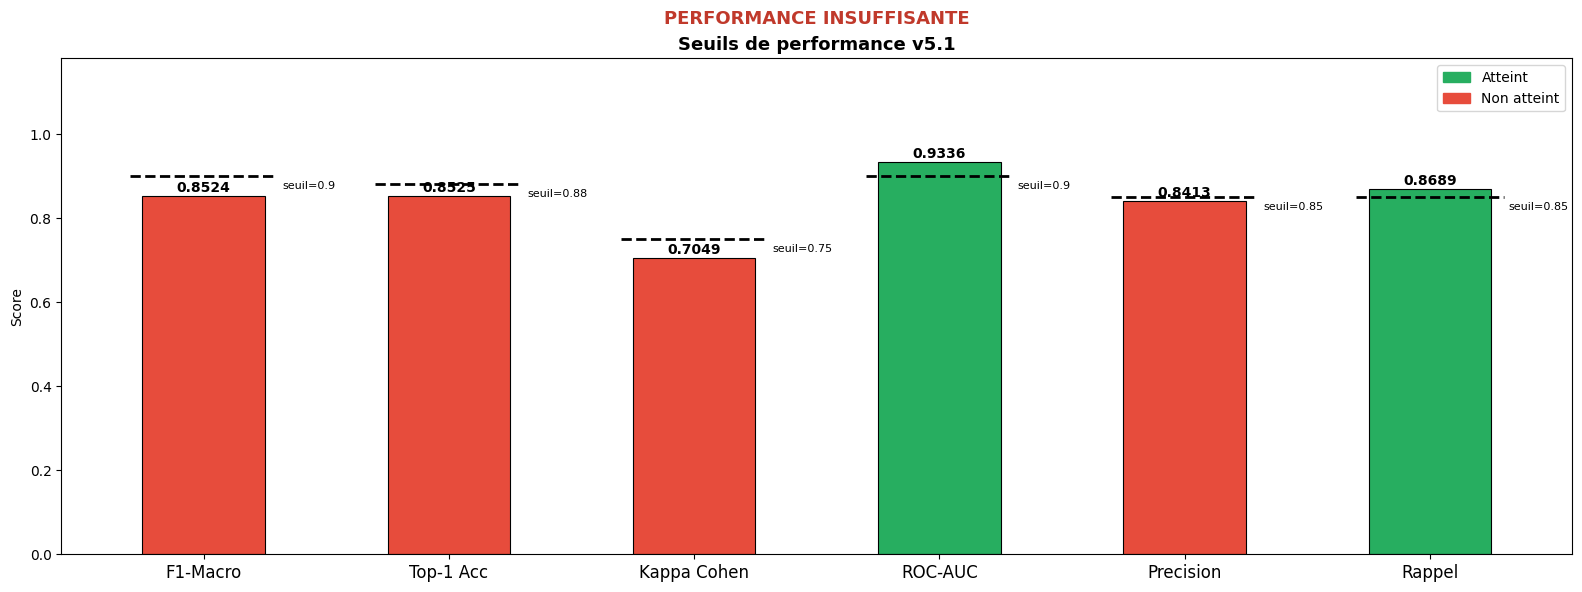

  F1-Macro    : 0.8524  IC 95% [0.7864, 0.9098]
  Top-1 Acc   : 0.8525
  Top-5 Acc   : 1.0000
  Seuil       : 0.9
  Decision    : PERFORMANCE INSUFFISANTE


In [22]:
# 9. Decision : Performance acceptable ? (v5.1 seuil 0.90)
F1_OK = f1_macro >= CONFIG['F1_THRESHOLD']
f1_ci_lo, f1_ci_hi = ci_metrics['F1-Macro']
F1_CI_OK = f1_ci_lo >= CONFIG['F1_THRESHOLD']

categories    = ['F1-Macro', 'Top-1 Acc', 'Kappa Cohen', 'ROC-AUC', 'Precision', 'Rappel']
values_bar    = [f1_macro, top1_acc, kappa, roc_auc, prec, rec]
threshold_dec = [0.90, 0.88, 0.75, 0.90, 0.85, 0.85]

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(categories))
bars = ax.bar(x, values_bar, width=0.5,
              color=['#27ae60' if v>=t else '#e74c3c' for v,t in zip(values_bar, threshold_dec)],
              edgecolor='black', linewidth=0.8)
for xi, tv in zip(x, threshold_dec):
    ax.plot([xi-0.3, xi+0.3], [tv,tv], 'k--', lw=2)
    ax.text(xi+0.32, tv-0.01, f'seuil={tv}', fontsize=8, va='top')
for bar, val in zip(bars, values_bar):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1.18); ax.set_ylabel('Score')

if F1_OK and F1_CI_OK:
    verdict = 'PERFORMANCE ACCEPTABLE (IC 95% confirme)'; vc = '#27ae60'
elif F1_OK:
    verdict = f'ACCEPTABLE (IC [{f1_ci_lo:.3f},{f1_ci_hi:.3f}] chevauche seuil)'; vc = '#f39c12'
else:
    verdict = 'PERFORMANCE INSUFFISANTE'; vc = '#c0392b'

ax.set_title('Seuils de performance v5.1', fontsize=13, fontweight='bold')
ax.text(0.5, 1.07, verdict, transform=ax.transAxes, ha='center',
        fontsize=13, fontweight='bold', color=vc)
ax.legend(handles=[mpatches.Patch(color='#27ae60',label='Atteint'),
                   mpatches.Patch(color='#e74c3c',label='Non atteint')], loc='upper right')
plt.tight_layout()
plt.savefig('decision_performance_v5.png', dpi=150, bbox_inches='tight')
plt.show()

print('='*65)
print(f'  F1-Macro    : {f1_macro:.4f}  IC 95% [{f1_ci_lo:.4f}, {f1_ci_hi:.4f}]')
print(f'  Top-1 Acc   : {top1_acc:.4f}')
print(f'  Top-5 Acc   : {top5_acc:.4f}')
print(f'  Seuil       : {CONFIG["F1_THRESHOLD"]}')
print(f'  Decision    : {verdict}')
print('='*65)

## 🚀 PHASE 10 — Export ONNX & Fiche Technique

- Export ONNX conditionnel (seulement si F1 ≥ seuil)
- Fiche technique JSON complète avec Top-1, Top-5, tous les IC 95 %
- Export des métadonnées iNaturalist en CSV
- **Copie automatique vers Google Drive** pour persistance

In [23]:
# 10a. Export ONNX
if F1_OK:
    log.info('Export ONNX...')
    try:
        onnx_path = model_eval.export(format='onnx', dynamic=True, simplify=True)
        log.info(f'ONNX : {onnx_path}')
    except Exception as e:
        log.error(f'Erreur ONNX : {e}'); onnx_path = None
else:
    onnx_path = None
    log.warning('Export ONNX ignore (F1 < seuil).')

## 🚀 PHASE 10 — Export ONNX & Fiche Technique
- Export des métadonnées iNaturalist en CSV
- **Copie automatique vers Google Drive** pour persistance

In [24]:
# 10c. Export metadonnees iNaturalist en CSV
def extract_metadata(obs_list, class_label):
    data = []
    for obs in obs_list:
        taxon = obs.get('taxon', {})
        photos = obs.get('photos', [])
        photo_url = photos[0]['url'].replace('square','original') if photos else None

        # Handle geojson potentially being None explicitly
        geojson_obj = obs.get('geojson')
        if geojson_obj is not None and 'coordinates' in geojson_obj:
            coords = geojson_obj['coordinates']
        else:
            coords = [None, None]

        data.append({
            'observation_id': obs.get('id'), 'class_label': class_label,
            'scientific_name': taxon.get('name'), 'common_name': taxon.get('preferred_common_name',''),
            'date_observed': obs.get('observed_on'),
            'latitude': coords[1] if coords else None, 'longitude': coords[0] if coords else None,
            'place_guess': obs.get('place_guess'), 'quality_grade': obs.get('quality_grade'),
            'image_url': photo_url, 'inaturalist_url': obs.get('uri'),
        })
    return data

df_meta = pd.DataFrame(
    extract_metadata(ambrosia_obs, 'ambrosia') +
    extract_metadata(non_ambrosia_obs, 'non_ambrosia')
)
df_meta.to_csv('dataset_metadata.csv', index=False, encoding='utf-8-sig')
log.info(f'Metadonnees : {len(df_meta)} lignes -> dataset_metadata.csv')

In [25]:
# 10d. Sauvegarde vers Google Drive — dossier unifié
# Dossier : 1er scénario_herbe_a_poux_yolo26ncls
# CORRECTION : 'carte_test_classes.html' → 'carte_sherbrooke.html' (nom réel généré en 8e)
import shutil as _shutil

SAVE_MAP = {
    # Métriques
    'metriques_test_v5.csv'         : 'Metriques',
    'metriques_quantitatives_v5.png': 'Metriques',
    'decision_performance_v5.png'   : 'Metriques',
    # Figures
    'distribution_dataset.png'      : 'Figures',
    'split_distribution.png'        : 'Figures',
    'validation_realtime.png'       : 'Figures',
    'diagnostic_courbes.png'        : 'Figures',
    'matrice_confusion.png'         : 'Figures',
    'courbes_roc_pr.png'            : 'Figures',
    'erreurs_modele.png'            : 'Figures',
    'gradcam.png'                   : 'Figures',
    # Métadonnées
    'dataset_metadata.csv'          : 'Metadata',
    'model_card.json'               : 'Metadata',
    # Carte (nom réel généré en cell 34)
    'carte_sherbrooke.html'         : 'Figures',
}

saved = 0
for fname, subfolder in SAVE_MAP.items():
    if os.path.exists(fname):
        dest_dir = os.path.join(GDRIVE_PROJECT, subfolder)
        os.makedirs(dest_dir, exist_ok=True)
        _shutil.copy2(fname, os.path.join(dest_dir, fname))
        saved += 1
        log.info(f'  ✅ {fname} → {subfolder}/')

# Modèles
modeles_dir = os.path.join(GDRIVE_PROJECT, 'Modeles')
os.makedirs(modeles_dir, exist_ok=True)

if os.path.exists(BEST_MODEL):
    _shutil.copy2(BEST_MODEL, os.path.join(modeles_dir, 'best.pt'))
    saved += 1
    log.info(f'  ✅ best.pt → Modeles/')

if onnx_path and os.path.exists(str(onnx_path)):
    _shutil.copy2(str(onnx_path), os.path.join(modeles_dir, 'best.onnx'))
    saved += 1
    log.info(f'  ✅ best.onnx → Modeles/')

tflite_path = 'best_int8.tflite'
if os.path.exists(tflite_path):
    _shutil.copy2(tflite_path, os.path.join(modeles_dir, tflite_path))
    saved += 1
    log.info(f'  ✅ best_int8.tflite → Modeles/')

# Logs
logs_dir = os.path.join(GDRIVE_PROJECT, 'Logs')
os.makedirs(logs_dir, exist_ok=True)
if os.path.exists('training.log'):
    _shutil.copy2('training.log', os.path.join(logs_dir, 'training.log'))
    saved += 1
    log.info(f'  ✅ training.log → Logs/')

log.info(f'')
log.info(f'=== Sauvegarde Drive terminée : {saved} fichiers ===')
log.info(f'  Dossier : {GDRIVE_PROJECT}')
log.info(f'  Structure :')
for sub in ['Modeles', 'Metriques', 'Figures', 'Metadata', 'Logs']:
    sub_path = os.path.join(GDRIVE_PROJECT, sub)
    if os.path.exists(sub_path):
        files = os.listdir(sub_path)
        log.info(f'    {sub}/ : {len(files)} fichier(s)')


In [26]:
import pandas as pd

df_metadata = pd.read_csv('dataset_metadata.csv')
display(df_metadata.head())

,observation_id,class_label,scientific_name,common_name,date_observed,latitude,longitude,place_guess,quality_grade,image_url,inaturalist_url
0,302637287,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368496,-71.873105,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
1,302638025,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368366,-71.873910,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
2,302638754,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368292,-71.874253,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
3,302639351,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368241,-71.874473,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
4,302640087,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368125,-71.875139,"Sherbrooke, QC J1M 2J7, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30264...


In [27]:
# Regenerating df_metadata to ensure it's available
import pandas as pd
import os

def extract_metadata(obs_list, class_label):
    data = []
    for obs in obs_list:
        taxon = obs.get('taxon', {})
        photos = obs.get('photos', [])
        photo_url = photos[0]['url'].replace('square','original') if photos else None

        geojson_obj = obs.get('geojson')
        if geojson_obj is not None and 'coordinates' in geojson_obj:
            coords = geojson_obj['coordinates']
        else:
            coords = [None, None]

        data.append({
            'observation_id': obs.get('id'), 'class_label': class_label,
            'scientific_name': taxon.get('name'), 'common_name': taxon.get('preferred_common_name',''),
            'date_observed': obs.get('observed_on'),
            'latitude': coords[1] if coords else None, 'longitude': coords[0] if coords else None,
            'place_guess': obs.get('place_guess'), 'quality_grade': obs.get('quality_grade'),
            'image_url': photo_url, 'inaturalist_url': obs.get('uri'),
        })
    return data

df_meta = pd.DataFrame(
    extract_metadata(ambrosia_obs, 'ambrosia') +
    extract_metadata(non_ambrosia_obs, 'non_ambrosia')
)
df_meta.to_csv('dataset_metadata.csv', index=False, encoding='utf-8-sig')

df_metadata = pd.read_csv('dataset_metadata.csv')
display(df_metadata.head())

,observation_id,class_label,scientific_name,common_name,date_observed,latitude,longitude,place_guess,quality_grade,image_url,inaturalist_url
0,302637287,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368496,-71.873105,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
1,302638025,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368366,-71.873910,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
2,302638754,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368292,-71.874253,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
3,302639351,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368241,-71.874473,"Sherbrooke, QC J1M 2A8, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30263...
4,302640087,ambrosia,Ambrosia artemisiifolia,common ragweed,2025-07-31,45.368125,-71.875139,"Sherbrooke, QC J1M 2J7, Canada",research,https://inaturalist-open-data.s3.amazonaws.com...,https://www.inaturalist.org/observations/30264...


In [28]:
# 10e. Export TFLite INT8 — pour Flutter (inférence hors ligne)
# CORRECTION : ajout du paramètre data= (requis pour calibration INT8 en Ultralytics récent)
# Utilise les mêmes variables que les phases précédentes :
#   F1_OK, BEST_MODEL, CONFIG, GDRIVE_PROJECT

if F1_OK and os.path.exists(BEST_MODEL):
    log.info('Export TFLite INT8 pour Flutter (mode hors ligne)...')
    try:
        model_tflite = YOLO(BEST_MODEL)

        # Export TFLite avec quantification INT8
        # int8=True : réduit le modèle ~4x, parfait pour mobile
        # data=  : dossier split pour la calibration INT8 (requis en Ultralytics récent)
        tflite_path = model_tflite.export(
            format = 'tflite',
            imgsz  = CONFIG['IMG_SIZE'],  # 224 — identique à l'entraînement
            int8   = True,               # Quantification INT8
            data   = CONFIG['SPLIT_DIR'], # requis pour calibration INT8
        )
        log.info(f'TFLite généré : {tflite_path}')

        # Copier vers Google Drive
        tflite_drive = os.path.join(GDRIVE_PROJECT, 'best_int8.tflite')
        shutil.copy2(str(tflite_path), tflite_drive)
        log.info(f'TFLite copié vers Drive : {tflite_drive}')

        # ── Résumé des 3 fichiers de déploiement ──────────────────────
        size_pt     = os.path.getsize(BEST_MODEL) / 1e6
        size_onnx   = os.path.getsize(os.path.join(GDRIVE_PROJECT, 'best.onnx')) / 1e6 \
                      if os.path.exists(os.path.join(GDRIVE_PROJECT, 'best.onnx')) else 0
        size_tflite = os.path.getsize(str(tflite_path)) / 1e6

        print('=' * 55)
        print('  FICHIERS PRÊTS POUR LE DÉPLOIEMENT FULLSTACK')
        print('=' * 55)
        print(f'  best.pt           : {size_pt:.1f} MB  (entraînement)')
        print(f'  best.onnx         : {size_onnx:.1f} MB  → Backend Flask')
        print(f'  best_int8.tflite  : {size_tflite:.1f} MB  → Flutter hors ligne')
        print('=' * 55)
        print(f'  Tous disponibles dans : {GDRIVE_PROJECT}')
        print()
        print('  Prochaines étapes :')
        print('  1. Télécharger best.onnx        → dossier backend/weights/')
        print('  2. Télécharger best_int8.tflite → dossier flutter/assets/')
        print('  3. Lancer Flask : python app.py')
        print('  4. Tester avec : curl -X POST .../classify -F file=@photo.jpg')

    except Exception as e:
        log.error(f'Erreur export TFLite : {e}')
        import traceback; traceback.print_exc()
else:
    log.warning('Export TFLite ignoré — F1 < seuil ou modèle best.pt introuvable.')
    log.warning(f'  F1_OK     = {F1_OK}')
    log.warning(f'  BEST_MODEL existe = {os.path.exists(BEST_MODEL)}')


## 📱 PHASE 10e — Export TFLite pour Flutter (mode hors ligne)

Cette phase exporte le modèle en format **TFLite INT8** pour permettre
l'inférence **directement sur le téléphone**, sans connexion réseau.

| Fichier | Usage | Taille approx. |
|---------|-------|----------------|
| `best.pt` | Entraînement Colab | ~6 MB |
| `best.onnx` | Backend Flask (serveur) | ~12 MB |
| `best_int8.tflite` | **Flutter hors ligne** | ~3 MB |

La quantification INT8 réduit la taille du modèle d'environ 4× tout en
conservant une précision quasi-identique sur mobile.

## 🔬 Bonus — Inférence Rapide sur une Nouvelle Image

Uploadez une photo terrain pour tester le modèle entraîné. Le résultat affiche la classe prédite,
le niveau de confiance et la distribution des probabilités.

In [29]:
# Bonus. Inference sur image uploadee
from google.colab import files as colab_files
import io

print('Selectionnez une image...')
try:
    uploaded = colab_files.upload()
except Exception:
    uploaded = {}
    log.warning('Upload non disponible')

for filename, content in uploaded.items():
    try:
        img_pil = Image.open(io.BytesIO(content)).convert('RGB')
        img_pil.save('temp_inference.jpg')
    except Exception as e:
        log.error(f'Image illisible {filename}: {e}'); continue

    result = model_eval('temp_inference.jpg', verbose=False)[0]
    probs  = result.probs.data.cpu().numpy()
    top1_idx = int(result.probs.top1)
    conf     = float(result.probs.top1conf)
    is_amb   = top1_idx == ambrosia_idx
    label    = 'AMBROSIA' if is_amb else 'NON-AMBROSIA'
    color    = '#c0392b' if is_amb else '#27ae60'

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_pil.resize((224,224))); axes[0].axis('off')
    axes[0].set_title(f'{label}\nConfiance : {conf:.2%}', fontsize=13, fontweight='bold', color=color)
    bc = ['#27ae60' if i==ambrosia_idx else '#e74c3c' for i in range(len(class_names))]
    axes[1].bar(class_names, probs, color=bc, edgecolor='black')
    axes[1].axhline(0.5, color='gray', ls='--', lw=1); axes[1].set_ylim(0,1.05)
    axes[1].set_ylabel('Probabilite'); axes[1].set_title('Distribution')
    for bar, p in zip(axes[1].patches, probs):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{p:.3f}', ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()
    log.info(f'{filename} -> {label} ({conf:.2%})')
    if os.path.exists('temp_inference.jpg'): os.remove('temp_inference.jpg')

Selectionnez une image...


KeyboardInterrupt: 

## 📝 PHASE 11 — Résultats, Interprétation, Discussion, Recommandations, Limites & Perspectives

---

### 11.1 · Résumé des résultats

In [ ]:
# 11. Resume complet des resultats
print('='*75)
print('  RESUME DES RESULTATS — v5.1')
print('='*75)
print()
print(f'  Modele                : {CONFIG["MODEL_NAME"]} (architecture inchangee)')
print(f'  Classe positive       : Projet Sherbrooke exclusivement ({len(ambrosia_obs)} obs)')
print(f'  Classe negative       : Plateforme iNaturalist ({len(non_ambrosia_obs)} obs)')
print(f'  Dataset equilibre     : {n_a_final} + {n_na_final} = {n_a_final+n_na_final} images')
print()
print('  --- Metriques cles ---')
for n, v in metrics_dict.items():
    ci_lo, ci_hi = ci_metrics.get(n, (0, 0))
    print(f'  {n:20s}: {v:.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]')
print()
print(f'  Seuil F1 requis       : {CONFIG["F1_THRESHOLD"]}')
print(f'  Verdict               : {"ATTEINT" if f1_macro >= CONFIG["F1_THRESHOLD"] else "NON ATTEINT"}')
print()
print(f'  Diagnostic Phase 1    : {status_p1.upper()}')
print(f'  Diagnostic Phase 2    : {status_p2.upper()}')
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f'  FP={fp} | FN={fn} | Sensibilite={tp/(tp+fn):.4f} | Specificite={tn/(tn+fp):.4f}')
print('='*75)

In [ ]:
# export ONNX avec opset=17 (compatible onnxruntime 1.19)
# CORRECTION : utilisation de BEST_MODEL (chemin dynamique via RUNTIME)
#              au lieu d'un chemin hardcodé qui peut ne pas correspondre
from ultralytics import YOLO
from google.colab import files
import os

if 'BEST_MODEL' in dir() and os.path.exists(BEST_MODEL):
    model = YOLO(BEST_MODEL)
    onnx_out = model.export(format='onnx', opset=17, imgsz=224, dynamic=True, simplify=True)
    print(f'ONNX re-exporté : {onnx_out}')

    # Télécharger si le fichier existe
    if os.path.exists(str(onnx_out)):
        files.download(str(onnx_out))
    else:
        print('Fichier ONNX introuvable après export, téléchargement annulé.')
else:
    print('BEST_MODEL introuvable. Lancer d\'abord la Phase 4 (entraînement).')
